# 08 — Strategy Monitoring and Diagnostics

This notebook converts the research and attribution evidence from Notebooks 02–07 into a reusable strategy-monitoring framework.

The objective is not to discover or reselect strategies. Instead, the notebook asks whether the retained signals and selected portfolio implementations continue to behave within historically understood ranges.

The monitoring framework covers:

1. input integrity and cross-notebook reconciliation;
2. retained-signal health through time;
3. portfolio, long-basket and short-basket market exposure;
4. rolling performance, volatility, downside risk and drawdown state;
5. security, sector and contribution concentration;
6. turnover, transaction costs, missing returns and capacity;
7. structural failures and historically calibrated warning indicators; and
8. a consolidated latest-date monitoring snapshot.

Composite Score rebalanced every 21 trading days remains the primary specification. Fixed 50/50 Sleeves and Pure Inverse Volatility, each rebalanced every 10 trading days, are retained as transparent comparison implementations. All use offset zero and transaction costs of 10 basis points per unit of turnover.

Historical warning thresholds are descriptive diagnostics rather than validated trading rules. They identify unusual states relative to this sample but do not by themselves establish structural deterioration or justify portfolio intervention.

The final outputs are designed to support Notebook 09's implementation decision and the downstream Streamlit monitoring dashboard.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet

pd.set_option(
    "display.max_columns",
    100,
)
pd.set_option(
    "display.width",
    160,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)


TRADING_DAYS_PER_YEAR = 252
SIGNAL_MONITORING_WINDOW = 252
RISK_MONITORING_WINDOW = 126
PERFORMANCE_MONITORING_WINDOW = 252

MIN_CROSS_SECTIONAL_OBSERVATIONS = 30
MONITORING_TOLERANCE = 1e-12

FORWARD_RETURN_COLUMN = "forward_ret_5d"

FACTOR_COLUMNS = {
    "Momentum": "mom_12_1m_z",
    "Realised Volatility": "realised_vol_63_z",
}

EXPECTED_IMPLEMENTATIONS = pd.DataFrame(
    [
        {
            "portfolio": "Composite Score",
            "rebalance_frequency": 21,
            "rebalance_offset": 0,
            "role": "Primary specification",
        },
        {
            "portfolio": "Fixed 50/50 Sleeves",
            "rebalance_frequency": 10,
            "rebalance_offset": 0,
            "role": "Transparent sleeve benchmark",
        },
        {
            "portfolio": "Pure Inverse Volatility",
            "rebalance_frequency": 10,
            "rebalance_offset": 0,
            "role": "Risk-based sleeve benchmark",
        },
    ]
)

PORTFOLIO_ORDER = EXPECTED_IMPLEMENTATIONS["portfolio"].tolist()

## 1. Inputs and cross-notebook audit

Notebook 08 consumes the frozen outputs produced by Notebook 06 and used in Notebook 07. It does not reconstruct portfolio weights or rerun the frequency-selection experiment.

The factor panel supplies retained signals, forward returns, sector classifications, rolling stock betas and liquidity data. The attribution handoff supplies the selected portfolio specifications, daily portfolio results, holdings, trades, security contributions and benchmark returns.

The audit below verifies:

- required schemas;
- unique dataset keys;
- selected implementation specifications;
- common portfolio and benchmark dates;
- transaction-cost and exposure identities; and
- the availability of the security-level inputs required by later diagnostics.

In [2]:
DATASET_FILENAMES = {
    "factor_panel": "factor_panel.parquet",
    "selected_implementations": ("attribution_selected_implementations.parquet"),
    "portfolio_daily": "attribution_portfolio_daily.parquet",
    "security_holdings": ("attribution_security_holdings.parquet"),
    "security_daily": "attribution_security_daily.parquet",
    "target_weights": "attribution_target_weights.parquet",
    "benchmark_daily": "attribution_benchmark_daily.parquet",
}

datasets = {
    dataset_name: load_parquet(PROCESSED_DATA_DIR / filename)
    for dataset_name, filename in DATASET_FILENAMES.items()
}

for dataset in datasets.values():
    if "date" in dataset.columns:
        dataset["date"] = pd.to_datetime(dataset["date"])

factor_panel = datasets["factor_panel"]
selected_implementations = datasets["selected_implementations"]
portfolio_daily = datasets["portfolio_daily"]
security_holdings = datasets["security_holdings"]
security_daily = datasets["security_daily"]
target_weights = datasets["target_weights"]
benchmark_daily = datasets["benchmark_daily"]

for dataset in [
    factor_panel,
    portfolio_daily,
    security_holdings,
    security_daily,
    target_weights,
    benchmark_daily,
]:
    sort_columns = [
        column
        for column in [
            "portfolio",
            "date",
            "ticker",
            "benchmark",
        ]
        if column in dataset.columns
    ]

    dataset.sort_values(
        sort_columns,
        inplace=True,
    )

    dataset.reset_index(
        drop=True,
        inplace=True,
    )

In [3]:
REQUIRED_COLUMNS = {
    "factor_panel": {
        "date",
        "ticker",
        "forward_ret_1d",
        "forward_ret_5d",
        "mom_12_1m_z",
        "realised_vol_63_z",
        "sector",
        "beta_126",
        "close",
        "volume",
        "dollar_volume",
    },
    "selected_implementations": {
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "role",
    },
    "portfolio_daily": {
        "date",
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "role",
        "is_rebalance",
        "long_return",
        "short_return",
        "gross_return",
        "net_return",
        "turnover",
        "transaction_cost",
        "transaction_cost_bps",
        "long_exposure",
        "short_exposure",
        "net_exposure",
        "gross_exposure",
        "missing_return_weight",
    },
    "security_holdings": {
        "date",
        "ticker",
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "role",
        "pre_trade_weight",
        "weight",
        "trade",
    },
    "security_daily": {
        "date",
        "ticker",
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "role",
        "weight",
        "trade",
        "asset_return",
        "absolute_trade_weight",
        "gross_contribution",
        "long_contribution",
        "short_contribution",
        "transaction_cost_contribution",
        "net_contribution",
        "long_exposure_contribution",
        "short_exposure_contribution",
        "missing_return_weight_contribution",
        "holding_side",
    },
    "target_weights": {
        "date",
        "ticker",
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "role",
        "weight",
    },
    "benchmark_daily": {
        "date",
        "benchmark",
        "benchmark_return",
    },
}

for dataset_name, required_columns in REQUIRED_COLUMNS.items():
    missing_columns = required_columns - set(datasets[dataset_name].columns)

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: " f"{sorted(missing_columns)}"
        )

In [4]:
KEY_COLUMNS = {
    "factor_panel": [
        "date",
        "ticker",
    ],
    "selected_implementations": [
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
    ],
    "portfolio_daily": [
        "portfolio",
        "date",
    ],
    "security_holdings": [
        "portfolio",
        "date",
        "ticker",
    ],
    "security_daily": [
        "portfolio",
        "date",
        "ticker",
    ],
    "target_weights": [
        "portfolio",
        "date",
        "ticker",
    ],
    "benchmark_daily": [
        "benchmark",
        "date",
    ],
}

input_audit_rows = []

for dataset_name, dataset in datasets.items():
    duplicate_key_rows = dataset.duplicated(
        KEY_COLUMNS[dataset_name],
        keep=False,
    ).sum()

    input_audit_rows.append(
        {
            "dataset": dataset_name,
            "rows": len(dataset),
            "columns": len(dataset.columns),
            "start_date": (
                dataset["date"].min() if "date" in dataset.columns else pd.NaT
            ),
            "end_date": (
                dataset["date"].max() if "date" in dataset.columns else pd.NaT
            ),
            "duplicate_key_rows": duplicate_key_rows,
        }
    )

input_audit = pd.DataFrame(input_audit_rows)

display(input_audit)

if input_audit["duplicate_key_rows"].gt(0).any():
    raise ValueError("Duplicate dataset keys found.")

,dataset,rows,columns,start_date,end_date,duplicate_key_rows
0,factor_panel,284249,44,2015-01-02,2026-07-02,0
1,selected_implementations,3,4,NaT,NaT,0
2,portfolio_daily,7905,20,2016-01-07,2026-07-01,0
3,security_holdings,778239,9,2016-01-07,2026-07-01,0
4,security_daily,407676,23,2016-01-07,2026-07-01,0
5,target_weights,64088,7,2016-01-14,2026-06-17,0
6,benchmark_daily,2635,3,2016-01-07,2026-07-01,0


In [5]:
SPECIFICATION_COLUMNS = [
    "portfolio",
    "rebalance_frequency",
    "rebalance_offset",
    "role",
]

expected_specifications = (
    EXPECTED_IMPLEMENTATIONS[SPECIFICATION_COLUMNS]
    .sort_values("portfolio")
    .reset_index(drop=True)
)

actual_specifications = (
    selected_implementations[SPECIFICATION_COLUMNS]
    .sort_values("portfolio")
    .reset_index(drop=True)
)

implementation_audit = expected_specifications.merge(
    actual_specifications,
    on=SPECIFICATION_COLUMNS,
    how="outer",
    indicator="match_status",
)

display(implementation_audit)

if not implementation_audit["match_status"].eq("both").all():
    raise ValueError(
        "Selected implementations do not match "
        "the frozen Notebook 08 specifications."
    )


configuration_audit_rows = []

for dataset_name in [
    "portfolio_daily",
    "security_holdings",
    "security_daily",
    "target_weights",
]:
    observed_specifications = datasets[dataset_name][
        SPECIFICATION_COLUMNS
    ].drop_duplicates()

    specification_check = observed_specifications.merge(
        expected_specifications,
        on=SPECIFICATION_COLUMNS,
        how="outer",
        indicator=True,
    )

    configuration_audit_rows.append(
        {
            "dataset": dataset_name,
            "observed_configurations": len(observed_specifications),
            "missing_expected_configurations": (
                specification_check["_merge"].eq("right_only").sum()
            ),
            "unexpected_configurations": (
                specification_check["_merge"].eq("left_only").sum()
            ),
        }
    )

configuration_audit = pd.DataFrame(configuration_audit_rows)

display(configuration_audit)

if (
    configuration_audit[
        [
            "missing_expected_configurations",
            "unexpected_configurations",
        ]
    ]
    .gt(0)
    .any()
    .any()
):
    raise ValueError(
        "Attribution datasets contain inconsistent " "portfolio specifications."
    )


if benchmark_daily["benchmark"].nunique() != 1:
    raise ValueError("Notebook 08 expects exactly one benchmark.")

if benchmark_daily["benchmark_return"].isna().any():
    raise ValueError("Benchmark returns contain missing values.")

benchmark_dates = pd.DatetimeIndex(benchmark_daily["date"].unique()).sort_values()

sample_audit_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = portfolio_daily.loc[
        portfolio_daily["portfolio"].eq(portfolio_name)
    ]

    portfolio_dates = pd.DatetimeIndex(portfolio_data["date"].unique()).sort_values()

    sample_audit_rows.append(
        {
            "portfolio": portfolio_name,
            "observations": len(portfolio_data),
            "start_date": portfolio_data["date"].min(),
            "end_date": portfolio_data["date"].max(),
            "missing_benchmark_dates": len(benchmark_dates.difference(portfolio_dates)),
            "extra_portfolio_dates": len(portfolio_dates.difference(benchmark_dates)),
            "transaction_cost_bps": (
                portfolio_data["transaction_cost_bps"].drop_duplicates().tolist()
            ),
        }
    )

analysis_sample_audit = pd.DataFrame(sample_audit_rows).set_index("portfolio")

display(analysis_sample_audit)

if (
    analysis_sample_audit[
        [
            "missing_benchmark_dates",
            "extra_portfolio_dates",
        ]
    ]
    .gt(0)
    .any()
    .any()
):
    raise ValueError("Portfolio and benchmark samples do not align.")

,portfolio,rebalance_frequency,rebalance_offset,role,match_status
0,Composite Score,21,0,Primary specification,both
1,Fixed 50/50 Sleeves,10,0,Transparent sleeve benchmark,both
2,Pure Inverse Volatility,10,0,Risk-based sleeve benchmark,both


,dataset,observed_configurations,missing_expected_configurations,unexpected_configurations
0,portfolio_daily,3,0,0
1,security_holdings,3,0,0
2,security_daily,3,0,0
3,target_weights,3,0,0


,observations,start_date,end_date,missing_benchmark_dates,extra_portfolio_dates,transaction_cost_bps
portfolio,,,,,,
Composite Score,2635,2016-01-07,2026-07-01,0,0,[10.0]
Fixed 50/50 Sleeves,2635,2016-01-07,2026-07-01,0,0,[10.0]
Pure Inverse Volatility,2635,2016-01-07,2026-07-01,0,0,[10.0]


In [6]:
accounting_audit_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = portfolio_daily.loc[
        portfolio_daily["portfolio"].eq(portfolio_name)
    ]

    audit_differences = {
        "long_short_return": (
            portfolio_data["long_return"]
            + portfolio_data["short_return"]
            - portfolio_data["gross_return"]
        )
        .abs()
        .max(),
        "net_return": (
            portfolio_data["gross_return"]
            - portfolio_data["transaction_cost"]
            - portfolio_data["net_return"]
        )
        .abs()
        .max(),
        "transaction_cost": (
            portfolio_data["turnover"]
            * portfolio_data["transaction_cost_bps"]
            / 10_000.0
            - portfolio_data["transaction_cost"]
        )
        .abs()
        .max(),
        "gross_exposure": (
            portfolio_data["long_exposure"]
            + portfolio_data["short_exposure"]
            - portfolio_data["gross_exposure"]
        )
        .abs()
        .max(),
        "net_exposure": (
            portfolio_data["long_exposure"]
            - portfolio_data["short_exposure"]
            - portfolio_data["net_exposure"]
        )
        .abs()
        .max(),
    }

    maximum_difference = max(audit_differences.values())

    accounting_audit_rows.append(
        {
            "portfolio": portfolio_name,
            **{
                f"max_abs_{name}_difference": value
                for name, value in audit_differences.items()
            },
            "maximum_absolute_difference": (maximum_difference),
            "audit_passes": (maximum_difference < MONITORING_TOLERANCE),
        }
    )

portfolio_accounting_audit = pd.DataFrame(accounting_audit_rows).set_index("portfolio")

display(portfolio_accounting_audit)

if not portfolio_accounting_audit["audit_passes"].all():
    raise ValueError("Portfolio accounting identities do not reconcile.")

,max_abs_long_short_return_difference,max_abs_net_return_difference,max_abs_transaction_cost_difference,max_abs_gross_exposure_difference,max_abs_net_exposure_difference,maximum_absolute_difference,audit_passes
portfolio,,,,,,,
Composite Score,0.0,0.0,0.0,0.0,0.0,0.0,True
Fixed 50/50 Sleeves,0.0,0.0,0.0,0.0,0.0,0.0,True
Pure Inverse Volatility,0.0,0.0,0.0,0.0,0.0,0.0,True


In [7]:
from alpha_research.validation import calculate_daily_ic


SIGNAL_MONITORING_MIN_PERIODS = 126
SIGNAL_STABILITY_LAGS = (1, 21)

RAW_FACTOR_COLUMNS = {
    "Momentum": "mom_12_1m_raw",
    "Realised Volatility": "realised_vol_63_raw",
}

## 2. Retained-signal health

The selected portfolios depend on two retained signals: 12–1 momentum and 63-day realised volatility. This section monitors whether their data availability, cross-sectional structure and realised predictive behaviour remain within historically understood ranges.

The diagnostics cover:

- signal and forward-return evaluation coverage;
- rolling five-day rank IC and positive-IC frequency;
- cross-sectional raw-signal dispersion;
- one-day and 21-day rank stability; and
- cross-sectional dependence between the two retained factors.

The five-day forward returns overlap across adjacent formation dates. Rolling IC measures are therefore descriptive monitoring statistics rather than independent observations suitable for conventional significance testing.

Signal-state diagnostics such as coverage, dispersion and factor dependence are available through the latest factor date. Realised IC is necessarily delayed until the corresponding five-day forward return becomes observable. These two information dates are kept separate throughout the monitoring framework.

#### Daily coverage and dispersion

In [8]:
def calculate_daily_signal_state(
    panel: pd.DataFrame,
    factor_name: str,
    score_column: str,
    raw_column: str,
    forward_return_column: str,
) -> pd.DataFrame:
    signal_data = panel[
        [
            "date",
            "ticker",
            score_column,
            raw_column,
            forward_return_column,
        ]
    ].copy()

    signal_data["signal_available"] = signal_data[score_column].notna()

    signal_data["evaluation_available"] = (
        signal_data[score_column].notna() & signal_data[forward_return_column].notna()
    )

    daily_state = (
        signal_data.groupby("date")
        .agg(
            universe_observations=("ticker", "nunique"),
            signal_observations=(
                "signal_available",
                "sum",
            ),
            evaluation_observations=(
                "evaluation_available",
                "sum",
            ),
            raw_median=(
                raw_column,
                "median",
            ),
            raw_q25=(
                raw_column,
                lambda values: values.quantile(0.25),
            ),
            raw_q75=(
                raw_column,
                lambda values: values.quantile(0.75),
            ),
        )
        .reset_index()
    )

    daily_state["signal_coverage"] = (
        daily_state["signal_observations"] / daily_state["universe_observations"]
    )

    daily_state["evaluation_coverage"] = (
        daily_state["evaluation_observations"] / daily_state["universe_observations"]
    )

    daily_state["raw_iqr"] = daily_state["raw_q75"] - daily_state["raw_q25"]

    daily_state["factor"] = factor_name

    return daily_state


signal_state_results = []

for factor_name, score_column in FACTOR_COLUMNS.items():
    signal_state_results.append(
        calculate_daily_signal_state(
            panel=factor_panel,
            factor_name=factor_name,
            score_column=score_column,
            raw_column=RAW_FACTOR_COLUMNS[factor_name],
            forward_return_column=FORWARD_RETURN_COLUMN,
        )
    )

signal_state_daily = (
    pd.concat(
        signal_state_results,
        ignore_index=True,
    )
    .sort_values(
        [
            "factor",
            "date",
        ]
    )
    .reset_index(drop=True)
)

signal_state_daily.head()

,date,universe_observations,signal_observations,evaluation_observations,raw_median,raw_q25,raw_q75,signal_coverage,evaluation_coverage,raw_iqr,factor
0,2015-01-02,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum
1,2015-01-05,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum
2,2015-01-06,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum
3,2015-01-07,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum
4,2015-01-08,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum


#### Rolling rank IC

In [9]:
daily_ic_results = []
rolling_ic_results = []

for factor_name, score_column in FACTOR_COLUMNS.items():
    factor_ic = calculate_daily_ic(
        panel=factor_panel,
        factor_column=score_column,
        forward_return_column=FORWARD_RETURN_COLUMN,
        method="spearman",
        min_observations=(MIN_CROSS_SECTIONAL_OBSERVATIONS),
    ).rename(
        columns={
            "observations": "ic_observations",
        }
    )

    factor_ic["factor"] = factor_name

    valid_factor_ic = factor_ic.dropna(subset=["ic"]).copy()

    valid_factor_ic["rolling_mean_ic_252"] = (
        valid_factor_ic["ic"]
        .rolling(
            SIGNAL_MONITORING_WINDOW,
            min_periods=SIGNAL_MONITORING_MIN_PERIODS,
        )
        .mean()
    )

    valid_factor_ic["rolling_positive_ic_fraction_252"] = (
        valid_factor_ic["ic"]
        .gt(0)
        .rolling(
            SIGNAL_MONITORING_WINDOW,
            min_periods=SIGNAL_MONITORING_MIN_PERIODS,
        )
        .mean()
    )

    valid_factor_ic["rolling_ic_observations_252"] = (
        valid_factor_ic["ic"]
        .rolling(
            SIGNAL_MONITORING_WINDOW,
            min_periods=1,
        )
        .count()
    )

    daily_ic_results.append(factor_ic)

    rolling_ic_results.append(
        valid_factor_ic[
            [
                "date",
                "factor",
                "rolling_mean_ic_252",
                "rolling_positive_ic_fraction_252",
                "rolling_ic_observations_252",
            ]
        ]
    )


daily_factor_ic = pd.concat(
    daily_ic_results,
    ignore_index=True,
)

rolling_factor_ic = pd.concat(
    rolling_ic_results,
    ignore_index=True,
)

daily_factor_ic.head()

,date,ic,ic_observations,factor
0,2015-01-02,NaN,0,Momentum
1,2015-01-05,NaN,0,Momentum
2,2015-01-06,NaN,0,Momentum
3,2015-01-07,NaN,0,Momentum
4,2015-01-08,NaN,0,Momentum


#### Rank stability

In [10]:
def calculate_rank_stability(
    panel: pd.DataFrame,
    factor_name: str,
    score_column: str,
    lags: tuple[int, ...],
    min_observations: int,
) -> pd.DataFrame:
    score_matrix = panel.pivot(
        index="date",
        columns="ticker",
        values=score_column,
    ).sort_index()

    stability = pd.DataFrame(
        {
            "date": score_matrix.index,
        }
    )

    for lag in lags:
        lagged_scores = score_matrix.shift(lag)

        overlapping_observations = (score_matrix.notna() & lagged_scores.notna()).sum(
            axis=1
        )

        rank_correlation = score_matrix.corrwith(
            lagged_scores,
            axis=1,
            method="spearman",
        )

        rank_correlation = rank_correlation.where(
            overlapping_observations >= min_observations
        )

        stability[f"rank_stability_{lag}d"] = rank_correlation.to_numpy()

        stability[f"rank_stability_{lag}d_observations"] = (
            overlapping_observations.to_numpy()
        )

    stability["factor"] = factor_name

    return stability


rank_stability_results = []

for factor_name, score_column in FACTOR_COLUMNS.items():
    rank_stability_results.append(
        calculate_rank_stability(
            panel=factor_panel,
            factor_name=factor_name,
            score_column=score_column,
            lags=SIGNAL_STABILITY_LAGS,
            min_observations=(MIN_CROSS_SECTIONAL_OBSERVATIONS),
        )
    )

factor_rank_stability = pd.concat(
    rank_stability_results,
    ignore_index=True,
)

factor_rank_stability.head()

,date,rank_stability_1d,rank_stability_1d_observations,rank_stability_21d,rank_stability_21d_observations,factor
0,2015-01-02,NaN,0,NaN,0,Momentum
1,2015-01-05,NaN,0,NaN,0,Momentum
2,2015-01-06,NaN,0,NaN,0,Momentum
3,2015-01-07,NaN,0,NaN,0,Momentum
4,2015-01-08,NaN,0,NaN,0,Momentum


#### Cross-factor dependence

In [11]:
factor_dependence_rows = []

factor_dependence_columns = list(FACTOR_COLUMNS.values())

for date, group in factor_panel.groupby("date"):
    valid_group = group[factor_dependence_columns].dropna()

    observations = len(valid_group)

    if observations >= MIN_CROSS_SECTIONAL_OBSERVATIONS:
        rank_correlation = valid_group[factor_dependence_columns[0]].corr(
            valid_group[factor_dependence_columns[1]],
            method="spearman",
        )
    else:
        rank_correlation = np.nan

    factor_dependence_rows.append(
        {
            "date": date,
            "factor_rank_correlation": rank_correlation,
            "observations": observations,
        }
    )


factor_dependence_daily = (
    pd.DataFrame(factor_dependence_rows).sort_values("date").reset_index(drop=True)
)

factor_dependence_daily["rolling_factor_rank_correlation_252"] = (
    factor_dependence_daily["factor_rank_correlation"]
    .rolling(
        SIGNAL_MONITORING_WINDOW,
        min_periods=SIGNAL_MONITORING_MIN_PERIODS,
    )
    .mean()
)

factor_dependence_daily.head()

,date,factor_rank_correlation,observations,rolling_factor_rank_correlation_252
0,2015-01-02,NaN,0,NaN
1,2015-01-05,NaN,0,NaN
2,2015-01-06,NaN,0,NaN
3,2015-01-07,NaN,0,NaN
4,2015-01-08,NaN,0,NaN


#### Consolidate and audit signal diagnostics

In [12]:
signal_health_daily = (
    signal_state_daily.merge(
        daily_factor_ic,
        on=[
            "date",
            "factor",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        rolling_factor_ic,
        on=[
            "date",
            "factor",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        factor_rank_stability,
        on=[
            "date",
            "factor",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "factor",
            "date",
        ]
    )
    .reset_index(drop=True)
)


signal_health_daily["ic_observation_difference"] = (
    signal_health_daily["evaluation_observations"]
    - signal_health_daily["ic_observations"]
)

maximum_ic_observation_difference = (
    signal_health_daily["ic_observation_difference"].abs().max()
)

print(
    "Maximum evaluation-versus-IC " "observation difference:",
    maximum_ic_observation_difference,
)

if maximum_ic_observation_difference != 0:
    raise ValueError("Signal evaluation and IC observation " "counts do not reconcile.")


def trailing_median(
    values: pd.Series,
) -> pd.Series:
    return (
        values.shift(1)
        .rolling(
            SIGNAL_MONITORING_WINDOW,
            min_periods=SIGNAL_MONITORING_MIN_PERIODS,
        )
        .median()
    )


signal_health_daily["trailing_raw_iqr_median_252"] = signal_health_daily.groupby(
    "factor"
)["raw_iqr"].transform(trailing_median)

signal_health_daily["raw_iqr_relative_to_trailing_median"] = (
    signal_health_daily["raw_iqr"] / signal_health_daily["trailing_raw_iqr_median_252"]
)

signal_health_daily.head()

Maximum evaluation-versus-IC observation difference: 0


,date,universe_observations,signal_observations,evaluation_observations,raw_median,raw_q25,raw_q75,signal_coverage,evaluation_coverage,raw_iqr,factor,ic,ic_observations,rolling_mean_ic_252,rolling_positive_ic_fraction_252,rolling_ic_observations_252,rank_stability_1d,rank_stability_1d_observations,rank_stability_21d,rank_stability_21d_observations,ic_observation_difference,trailing_raw_iqr_median_252,raw_iqr_relative_to_trailing_median
0,2015-01-02,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,NaN
1,2015-01-05,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,NaN
2,2015-01-06,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,NaN
3,2015-01-07,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,NaN
4,2015-01-08,97,0,0,NaN,NaN,NaN,0.0,0.0,NaN,Momentum,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,NaN


#### Full-sample summary

In [13]:
def positive_fraction(
    values: pd.Series,
) -> float:
    valid_values = values.dropna()

    if valid_values.empty:
        return np.nan

    return valid_values.gt(0).mean()


signal_health_summary = signal_health_daily.groupby("factor").agg(
    signal_dates=("date", "nunique"),
    start_date=("date", "min"),
    end_date=("date", "max"),
    mean_signal_coverage=(
        "signal_coverage",
        "mean",
    ),
    minimum_signal_coverage=(
        "signal_coverage",
        "min",
    ),
    evaluated_ic_dates=(
        "ic",
        "count",
    ),
    mean_rank_ic=(
        "ic",
        "mean",
    ),
    positive_ic_fraction=(
        "ic",
        positive_fraction,
    ),
    median_raw_iqr=(
        "raw_iqr",
        "median",
    ),
    median_rank_stability_1d=(
        "rank_stability_1d",
        "median",
    ),
    median_rank_stability_21d=(
        "rank_stability_21d",
        "median",
    ),
)

display(signal_health_summary.round(4))


factor_dependence_summary = (
    factor_dependence_daily["factor_rank_correlation"]
    .describe()
    .to_frame("factor_rank_correlation")
)

display(factor_dependence_summary.round(4))

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\3335966490.py:50: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(signal_health_summary.round(4))


,signal_dates,start_date,end_date,mean_signal_coverage,minimum_signal_coverage,evaluated_ic_dates,mean_rank_ic,positive_ic_fraction,median_raw_iqr,median_rank_stability_1d,median_rank_stability_21d
factor,,,,,,,,,,,
Momentum,2891,2015-01-02,2026-07-02,0.9101,0.0,2634,0.0197,0.5558,0.2960,0.9944,0.9047
Realised Volatility,2891,2015-01-02,2026-07-02,0.9775,0.0,2823,0.0253,0.5441,0.0997,0.9972,0.9120


,factor_rank_correlation
count,2639.0000
mean,0.0131
std,0.3302
min,-0.8024
25%,-0.2342
50%,0.0679
75%,0.2280
max,0.7394


#### Information-date audit and latest state

In [14]:
signal_availability_rows = []

for factor_name in FACTOR_COLUMNS:
    factor_health = signal_health_daily.loc[
        signal_health_daily["factor"].eq(factor_name)
    ]

    valid_signal_dates = factor_health.loc[
        factor_health["signal_observations"].ge(MIN_CROSS_SECTIONAL_OBSERVATIONS),
        "date",
    ]

    valid_ic_dates = factor_health.loc[
        factor_health["ic"].notna(),
        "date",
    ]

    latest_signal_date = valid_signal_dates.max()
    latest_evaluated_date = valid_ic_dates.max()

    signal_availability_rows.append(
        {
            "factor": factor_name,
            "latest_signal_date": latest_signal_date,
            "latest_evaluated_ic_date": (latest_evaluated_date),
            "unevaluated_signal_dates": (
                valid_signal_dates.gt(latest_evaluated_date).sum()
            ),
        }
    )


signal_availability_audit = pd.DataFrame(signal_availability_rows).set_index("factor")

display(signal_availability_audit)


latest_signal_state = (
    signal_health_daily.loc[
        signal_health_daily["signal_observations"].ge(MIN_CROSS_SECTIONAL_OBSERVATIONS)
    ]
    .sort_values(
        [
            "factor",
            "date",
        ]
    )
    .groupby(
        "factor",
        as_index=False,
    )
    .tail(1)
    .set_index("factor")[
        [
            "date",
            "universe_observations",
            "signal_observations",
            "signal_coverage",
            "raw_median",
            "raw_iqr",
            "raw_iqr_relative_to_trailing_median",
            "rank_stability_1d",
            "rank_stability_21d",
        ]
    ]
)

display(latest_signal_state.round(4))


latest_predictive_state = (
    signal_health_daily.dropna(subset=["ic"])
    .sort_values(
        [
            "factor",
            "date",
        ]
    )
    .groupby(
        "factor",
        as_index=False,
    )
    .tail(1)
    .set_index("factor")[
        [
            "date",
            "ic",
            "ic_observations",
            "rolling_mean_ic_252",
            "rolling_positive_ic_fraction_252",
            "rolling_ic_observations_252",
        ]
    ]
)

display(latest_predictive_state.round(4))


latest_factor_dependence = (
    factor_dependence_daily.dropna(subset=["factor_rank_correlation"])
    .tail(1)
    .set_index("date")
)

display(latest_factor_dependence.round(4))

,latest_signal_date,latest_evaluated_ic_date,unevaluated_signal_dates
factor,,,
Momentum,2026-07-02,2026-06-25,5
Realised Volatility,2026-07-02,2026-06-25,5


C:\Users\39521\AppData\Local\Temp\ipykernel_12180\1872701928.py:68: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_signal_state.round(4))


,date,universe_observations,signal_observations,signal_coverage,raw_median,raw_iqr,raw_iqr_relative_to_trailing_median,rank_stability_1d,rank_stability_21d
factor,,,,,,,,,
Momentum,2026-07-02,101,100,0.9901,0.1299,0.4806,1.3027,0.9949,0.9509
Realised Volatility,2026-07-02,101,100,0.9901,0.3074,0.1298,1.2200,0.9944,0.9469


C:\Users\39521\AppData\Local\Temp\ipykernel_12180\1872701928.py:96: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_predictive_state.round(4))


,date,ic,ic_observations,rolling_mean_ic_252,rolling_positive_ic_fraction_252,rolling_ic_observations_252
factor,,,,,,
Momentum,2026-06-25,-0.4995,100,0.0551,0.5992,252.0
Realised Volatility,2026-06-25,-0.1022,100,0.0444,0.5516,252.0


,factor_rank_correlation,observations,rolling_factor_rank_correlation_252
date,,,
2026-07-02,0.1629,100,0.0942


#### Signal-health overview

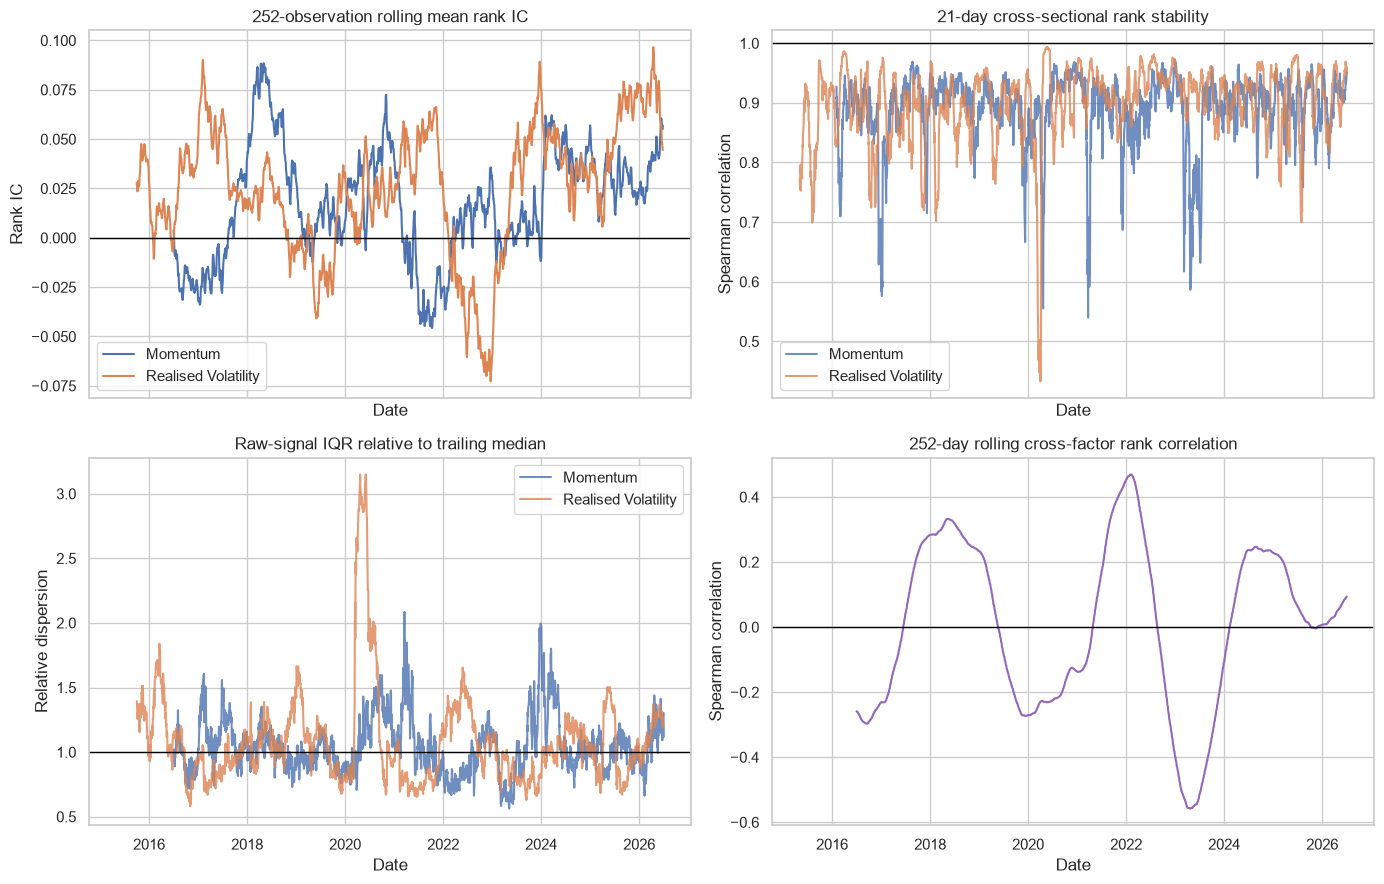

In [15]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
)

for factor_name in FACTOR_COLUMNS:
    factor_health = signal_health_daily.loc[
        signal_health_daily["factor"].eq(factor_name)
    ]

    axes[0, 0].plot(
        factor_health["date"],
        factor_health["rolling_mean_ic_252"],
        label=factor_name,
    )

    axes[0, 1].plot(
        factor_health["date"],
        factor_health["rank_stability_21d"],
        label=factor_name,
        alpha=0.8,
    )

    axes[1, 0].plot(
        factor_health["date"],
        factor_health["raw_iqr_relative_to_trailing_median"],
        label=factor_name,
        alpha=0.8,
    )


axes[1, 1].plot(
    factor_dependence_daily["date"],
    factor_dependence_daily["rolling_factor_rank_correlation_252"],
    color="tab:purple",
)


axes[0, 0].axhline(
    0,
    color="black",
    linewidth=1,
)
axes[0, 0].set_title("252-observation rolling mean rank IC")
axes[0, 0].set_ylabel("Rank IC")
axes[0, 0].legend()


axes[0, 1].axhline(
    1,
    color="black",
    linewidth=1,
)
axes[0, 1].set_title("21-day cross-sectional rank stability")
axes[0, 1].set_ylabel("Spearman correlation")
axes[0, 1].legend()


axes[1, 0].axhline(
    1,
    color="black",
    linewidth=1,
)
axes[1, 0].set_title("Raw-signal IQR relative to trailing median")
axes[1, 0].set_ylabel("Relative dispersion")
axes[1, 0].legend()


axes[1, 1].axhline(
    0,
    color="black",
    linewidth=1,
)
axes[1, 1].set_title("252-day rolling cross-factor rank correlation")
axes[1, 1].set_ylabel("Spearman correlation")


for axis in axes.flat:
    axis.set_xlabel("Date")

plt.tight_layout()
plt.show()

### Signal-health summary

Both retained signals appear healthy at the latest date. Momentum and realised volatility are available for 100 of the 101 stocks, and the five-day gap between the latest signal date and the latest evaluated IC date is expected because predictive performance is measured using five-day forward returns.

Recent predictive performance remains positive. The 252-day rolling mean rank IC is 0.055 for momentum and 0.044 for realised volatility, both above their full-sample averages. Although the latest individual IC observations are negative, a single cross-section is noisy and does not outweigh the healthier rolling evidence.

The signals also remain well differentiated and stable. Their cross-sectional dispersion is moderately above its recent norm, while their 21-day rank stability is approximately 0.95. This means the signals are not compressed and their stock rankings are changing gradually rather than erratically.

Finally, the latest 252-day cross-factor rank correlation is only 0.094, so momentum and realised volatility continue to provide largely distinct information.

Overall, there is no immediate signal-health warning. Future monitoring should focus on persistent deterioration in rolling IC, unusual rank instability, signal compression or a sustained rise in cross-factor dependence—not isolated daily observations.

## 3. Portfolio performance and market-risk state

This section converts the historical risk measures examined in Notebook 07 into reusable portfolio-state diagnostics.

The monitoring framework separates:

1. trailing net performance and risk;
2. current drawdown depth and duration;
3. realised market beta from portfolio returns; and
4. holdings-implied beta from current security weights and rolling stock betas.

Realised beta is backward-looking: it estimates the relationship between portfolio and benchmark returns over the previous 126 trading days. Holdings-implied beta is a point-in-time estimate:

$$
\widehat{\beta}^{\,\mathrm{holdings}}_{p,t}
=
\sum_i w_{i,t}\widehat{\beta}_{i,t}.
$$

The individual security betas use historical returns through the formation date and are therefore available when the corresponding portfolio weights are constructed.

For the long and short books, return-implied betas are signed contributions to portfolio beta. Holdings-based basket betas are also reported after normalising by the corresponding long or short exposure. The latter describe the market sensitivity of the underlying securities per unit of side exposure.

Differences between realised and holdings-implied beta can arise because one measure describes the preceding return window while the other describes current holdings. They are monitoring diagnostics rather than exact identities.

#### Rolling performance and drawdown state

In [16]:
def maximum_drawdown_from_array(
    returns: np.ndarray,
) -> float:
    wealth = np.cumprod(1.0 + returns)

    running_peak = np.maximum.accumulate(
        np.r_[
            1.0,
            wealth,
        ]
    )[1:]

    drawdown = wealth / running_peak - 1.0

    return drawdown.min()


def calculate_return_state(
    group: pd.DataFrame,
) -> pd.DataFrame:
    group = group.sort_values("date").copy()

    returns = group["return"]

    wealth = (1.0 + returns).cumprod()

    running_peak = np.maximum.accumulate(
        np.r_[
            1.0,
            wealth.to_numpy(),
        ]
    )[1:]

    group["wealth"] = wealth.to_numpy()

    group["drawdown"] = wealth.to_numpy() / running_peak - 1.0

    underwater = group["drawdown"].lt(0.0)

    underwater_episode = (~underwater).cumsum()

    group["drawdown_duration"] = (
        underwater.groupby(underwater_episode).cumsum().astype(int)
    )

    group["trailing_return_252"] = (1.0 + returns).rolling(
        PERFORMANCE_MONITORING_WINDOW,
        min_periods=(PERFORMANCE_MONITORING_WINDOW),
    ).apply(
        np.prod,
        raw=True,
    ) - 1.0

    rolling_mean_return = returns.rolling(
        PERFORMANCE_MONITORING_WINDOW,
        min_periods=(PERFORMANCE_MONITORING_WINDOW),
    ).mean()

    rolling_return_volatility = returns.rolling(
        PERFORMANCE_MONITORING_WINDOW,
        min_periods=(PERFORMANCE_MONITORING_WINDOW),
    ).std(ddof=1)

    group["rolling_sharpe_252"] = (
        rolling_mean_return / rolling_return_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)
    )

    group["annualised_volatility_126"] = returns.rolling(
        RISK_MONITORING_WINDOW,
        min_periods=(RISK_MONITORING_WINDOW),
    ).std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)

    squared_downside_return = returns.clip(upper=0.0).pow(2)

    group["annualised_downside_deviation_126"] = np.sqrt(
        squared_downside_return.rolling(
            RISK_MONITORING_WINDOW,
            min_periods=(RISK_MONITORING_WINDOW),
        ).mean()
        * TRADING_DAYS_PER_YEAR
    )

    group["maximum_drawdown_252"] = returns.rolling(
        PERFORMANCE_MONITORING_WINDOW,
        min_periods=(PERFORMANCE_MONITORING_WINDOW),
    ).apply(
        maximum_drawdown_from_array,
        raw=True,
    )

    return group


portfolio_return_state_input = portfolio_daily[
    [
        "date",
        "portfolio",
        "net_return",
    ]
].rename(
    columns={
        "net_return": "return",
    }
)

benchmark_return_state_input = (
    benchmark_daily[
        [
            "date",
            "benchmark_return",
        ]
    ]
    .rename(
        columns={
            "benchmark_return": "return",
        }
    )
    .assign(portfolio="SPY")
)

return_state_input = pd.concat(
    [
        portfolio_return_state_input,
        benchmark_return_state_input,
    ],
    ignore_index=True,
)

performance_risk_daily = pd.concat(
    [
        calculate_return_state(group)
        for _, group in return_state_input.groupby(
            "portfolio",
            sort=False,
        )
    ],
    ignore_index=True,
)

performance_risk_daily = performance_risk_daily.sort_values(
    [
        "portfolio",
        "date",
    ]
).reset_index(drop=True)

#### Rolling realised beta

In [17]:
portfolio_market_daily = (
    portfolio_daily.merge(
        benchmark_daily[
            [
                "date",
                "benchmark_return",
            ]
        ],
        on="date",
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)


REALISED_RETURN_STREAMS = {
    "gross": "gross_return",
    "net": "net_return",
    "long": "long_return",
    "short": "short_return",
}


realised_beta_parts = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = (
        portfolio_market_daily.loc[
            portfolio_market_daily["portfolio"].eq(portfolio_name)
        ]
        .sort_values("date")
        .copy()
    )

    market_returns = portfolio_data["benchmark_return"]

    rolling_market_variance = market_returns.rolling(
        RISK_MONITORING_WINDOW,
        min_periods=(RISK_MONITORING_WINDOW),
    ).var()

    for (
        return_stream,
        return_column,
    ) in REALISED_RETURN_STREAMS.items():
        stream_returns = portfolio_data[return_column]

        rolling_covariance = stream_returns.rolling(
            RISK_MONITORING_WINDOW,
            min_periods=(RISK_MONITORING_WINDOW),
        ).cov(market_returns)

        rolling_correlation = stream_returns.rolling(
            RISK_MONITORING_WINDOW,
            min_periods=(RISK_MONITORING_WINDOW),
        ).corr(market_returns)

        realised_beta_parts.append(
            pd.DataFrame(
                {
                    "date": (portfolio_data["date"].to_numpy()),
                    "portfolio": (portfolio_name),
                    "return_stream": (return_stream),
                    "realised_beta_126": (
                        rolling_covariance / rolling_market_variance
                    ).to_numpy(),
                    "market_correlation_126": (rolling_correlation.to_numpy()),
                }
            )
        )


realised_beta_daily = (
    pd.concat(
        realised_beta_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "portfolio",
            "return_stream",
            "date",
        ]
    )
    .reset_index(drop=True)
)

#### Holdings-implied beta

In [18]:
security_beta_panel = factor_panel[
    [
        "date",
        "ticker",
        "beta_126",
    ]
].copy()

holdings_with_beta = security_holdings.merge(
    security_beta_panel,
    on=[
        "date",
        "ticker",
    ],
    how="left",
    validate="many_to_one",
)

holdings_with_beta["long_weight"] = holdings_with_beta["weight"].clip(lower=0.0)

holdings_with_beta["short_weight"] = -holdings_with_beta["weight"].clip(upper=0.0)

holdings_with_beta["absolute_weight"] = holdings_with_beta["weight"].abs()

holdings_with_beta["beta_covered_gross_weight"] = holdings_with_beta[
    "absolute_weight"
].where(
    holdings_with_beta["beta_126"].notna(),
    0.0,
)

holdings_with_beta["long_beta_contribution"] = (
    holdings_with_beta["long_weight"] * holdings_with_beta["beta_126"]
)

holdings_with_beta["short_beta_contribution"] = (
    -holdings_with_beta["short_weight"] * holdings_with_beta["beta_126"]
)

holdings_with_beta["market_beta_contribution"] = (
    holdings_with_beta["weight"] * holdings_with_beta["beta_126"]
)


holdings_beta_daily = (
    holdings_with_beta.groupby(
        [
            "portfolio",
            "date",
        ],
        sort=False,
    )
    .agg(
        holdings_long_exposure=(
            "long_weight",
            "sum",
        ),
        holdings_short_exposure=(
            "short_weight",
            "sum",
        ),
        holdings_gross_exposure=(
            "absolute_weight",
            "sum",
        ),
        holdings_net_exposure=(
            "weight",
            "sum",
        ),
        beta_covered_gross_weight=(
            "beta_covered_gross_weight",
            "sum",
        ),
        holdings_long_beta_contribution=(
            "long_beta_contribution",
            lambda values: values.sum(min_count=1),
        ),
        holdings_short_beta_contribution=(
            "short_beta_contribution",
            lambda values: values.sum(min_count=1),
        ),
        holdings_market_beta=(
            "market_beta_contribution",
            lambda values: values.sum(min_count=1),
        ),
    )
    .reset_index()
)

holdings_beta_daily["long_basket_beta"] = (
    holdings_beta_daily["holdings_long_beta_contribution"]
    / holdings_beta_daily["holdings_long_exposure"]
)

holdings_beta_daily["short_basket_beta"] = (
    -holdings_beta_daily["holdings_short_beta_contribution"]
    / holdings_beta_daily["holdings_short_exposure"]
)

holdings_beta_daily["beta_coverage"] = (
    holdings_beta_daily["beta_covered_gross_weight"]
    / holdings_beta_daily["holdings_gross_exposure"]
).where(holdings_beta_daily["holdings_gross_exposure"].gt(0.0))

#### Audit holdings exposures

In [19]:
holdings_exposure_comparison = holdings_beta_daily.merge(
    portfolio_daily[
        [
            "date",
            "portfolio",
            "long_exposure",
            "short_exposure",
            "net_exposure",
            "gross_exposure",
        ]
    ],
    on=[
        "date",
        "portfolio",
    ],
    how="left",
    validate="one_to_one",
)

EXPOSURE_COMPARISONS = {
    "long": (
        "holdings_long_exposure",
        "long_exposure",
    ),
    "short": (
        "holdings_short_exposure",
        "short_exposure",
    ),
    "net": (
        "holdings_net_exposure",
        "net_exposure",
    ),
    "gross": (
        "holdings_gross_exposure",
        "gross_exposure",
    ),
}

for (
    exposure_name,
    (
        holdings_column,
        portfolio_column,
    ),
) in EXPOSURE_COMPARISONS.items():
    holdings_exposure_comparison[f"absolute_{exposure_name}_difference"] = (
        holdings_exposure_comparison[holdings_column]
        - holdings_exposure_comparison[portfolio_column]
    ).abs()


holdings_exposure_audit = holdings_exposure_comparison.groupby(
    "portfolio",
    sort=False,
).agg(
    max_abs_long_difference=(
        "absolute_long_difference",
        "max",
    ),
    max_abs_short_difference=(
        "absolute_short_difference",
        "max",
    ),
    max_abs_net_difference=(
        "absolute_net_difference",
        "max",
    ),
    max_abs_gross_difference=(
        "absolute_gross_difference",
        "max",
    ),
)

holdings_exposure_audit["maximum_absolute_difference"] = holdings_exposure_audit.max(
    axis=1
)

holdings_exposure_audit["audit_passes"] = (
    holdings_exposure_audit["maximum_absolute_difference"] < MONITORING_TOLERANCE
)

display(holdings_exposure_audit)

if not holdings_exposure_audit["audit_passes"].all():
    raise ValueError(
        "Security holdings do not reconcile " "with portfolio-level exposures."
    )

,max_abs_long_difference,max_abs_short_difference,max_abs_net_difference,max_abs_gross_difference,maximum_absolute_difference,audit_passes
portfolio,,,,,,
Composite Score,2.220446e-16,4.440892e-16,4.440892e-16,4.440892e-16,4.440892e-16,True
Fixed 50/50 Sleeves,2.220446e-16,2.220446e-16,3.747003e-16,4.440892e-16,4.440892e-16,True
Pure Inverse Volatility,2.220446e-16,2.220446e-16,2.983724e-16,4.440892e-16,4.440892e-16,True


#### Consolidate and audit beta state

In [20]:
realised_beta_wide = (
    realised_beta_daily.pivot(
        index=[
            "date",
            "portfolio",
        ],
        columns="return_stream",
        values="realised_beta_126",
    )
    .rename(columns=lambda name: (f"realised_{name}_beta_126"))
    .reset_index()
)

realised_beta_wide.columns.name = None


beta_state_daily = (
    holdings_beta_daily.merge(
        realised_beta_wide,
        on=[
            "date",
            "portfolio",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

beta_state_daily["beta_measurement_gap"] = (
    beta_state_daily["holdings_market_beta"]
    - beta_state_daily["realised_gross_beta_126"]
)

beta_state_daily["absolute_holdings_decomposition_difference"] = (
    beta_state_daily["holdings_long_beta_contribution"]
    + beta_state_daily["holdings_short_beta_contribution"]
    - beta_state_daily["holdings_market_beta"]
).abs()

beta_state_daily["absolute_realised_decomposition_difference"] = (
    beta_state_daily["realised_long_beta_126"]
    + beta_state_daily["realised_short_beta_126"]
    - beta_state_daily["realised_gross_beta_126"]
).abs()


beta_decomposition_audit = beta_state_daily.groupby(
    "portfolio",
    sort=False,
).agg(
    max_abs_holdings_difference=(
        "absolute_holdings_decomposition_difference",
        "max",
    ),
    max_abs_realised_difference=(
        "absolute_realised_decomposition_difference",
        "max",
    ),
)

beta_decomposition_audit["maximum_absolute_difference"] = beta_decomposition_audit.max(
    axis=1
)

beta_decomposition_audit["audit_passes"] = (
    beta_decomposition_audit["maximum_absolute_difference"] < MONITORING_TOLERANCE
)

display(beta_decomposition_audit)

if not beta_decomposition_audit["audit_passes"].all():
    raise ValueError("Long- and short-side beta contributions " "do not reconcile.")

,max_abs_holdings_difference,max_abs_realised_difference,maximum_absolute_difference,audit_passes
portfolio,,,,
Composite Score,5.551115e-16,1.110223e-15,1.110223e-15,True
Fixed 50/50 Sleeves,5.551115e-16,6.661338e-16,6.661338e-16,True
Pure Inverse Volatility,4.440892e-16,6.661338e-16,6.661338e-16,True


#### Latest portfolio and beta state

In [21]:
latest_portfolio_state = (
    performance_risk_daily.sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .groupby(
        "portfolio",
        sort=False,
    )
    .tail(1)
    .set_index("portfolio")
    .reindex(
        [
            *PORTFOLIO_ORDER,
            "SPY",
        ]
    )[
        [
            "date",
            "trailing_return_252",
            "rolling_sharpe_252",
            "annualised_volatility_126",
            "annualised_downside_deviation_126",
            "drawdown",
            "drawdown_duration",
            "maximum_drawdown_252",
        ]
    ]
)

display(latest_portfolio_state.round(4))


latest_beta_state = (
    beta_state_daily.sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .groupby(
        "portfolio",
        sort=False,
    )
    .tail(1)
    .set_index("portfolio")
    .reindex(PORTFOLIO_ORDER)[
        [
            "date",
            "holdings_market_beta",
            "realised_gross_beta_126",
            "realised_net_beta_126",
            "beta_measurement_gap",
            "holdings_long_beta_contribution",
            "holdings_short_beta_contribution",
            "realised_long_beta_126",
            "realised_short_beta_126",
            "long_basket_beta",
            "short_basket_beta",
            "beta_coverage",
        ]
    ]
)

display(latest_beta_state.round(4))

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\3326995126.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_portfolio_state.round(4))


,date,trailing_return_252,rolling_sharpe_252,annualised_volatility_126,annualised_downside_deviation_126,drawdown,drawdown_duration,maximum_drawdown_252
portfolio,,,,,,,,
Composite Score,2026-07-01,0.6092,1.6809,0.3675,0.2601,-0.0976,8,-0.1199
Fixed 50/50 Sleeves,2026-07-01,0.5257,1.7996,0.3010,0.2149,-0.0965,8,-0.0965
Pure Inverse Volatility,2026-07-01,0.5162,1.7679,0.3018,0.2162,-0.0966,8,-0.0966
SPY,2026-07-01,0.2142,1.6083,0.1412,0.0953,-0.0210,21,-0.0888


C:\Users\39521\AppData\Local\Temp\ipykernel_12180\3326995126.py:67: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_beta_state.round(4))


,date,holdings_market_beta,realised_gross_beta_126,realised_net_beta_126,beta_measurement_gap,holdings_long_beta_contribution,holdings_short_beta_contribution,realised_long_beta_126,realised_short_beta_126,long_basket_beta,short_basket_beta,beta_coverage
portfolio,,,,,,,,,,,,
Composite Score,2026-07-01,1.8273,1.9095,1.9077,-0.0822,1.8712,-0.0440,1.9636,-0.0541,1.8952,0.0454,1.0
Fixed 50/50 Sleeves,2026-07-01,1.4100,1.4508,1.4458,-0.0408,1.6114,-0.2014,1.5599,-0.1091,2.1387,0.2656,1.0
Pure Inverse Volatility,2026-07-01,1.4098,1.4541,1.4489,-0.0443,1.6116,-0.2018,1.5619,-0.1078,2.1381,0.2660,1.0


#### Historical beta ranges

In [22]:
evaluated_beta_state = beta_state_daily.dropna(
    subset=[
        "realised_gross_beta_126",
    ]
)

beta_state_history_summary = evaluated_beta_state.groupby(
    "portfolio",
    sort=False,
).agg(
    evaluated_dates=(
        "date",
        "count",
    ),
    tenth_pct_holdings_beta=(
        "holdings_market_beta",
        lambda values: values.quantile(0.10),
    ),
    median_holdings_beta=(
        "holdings_market_beta",
        "median",
    ),
    ninetieth_pct_holdings_beta=(
        "holdings_market_beta",
        lambda values: values.quantile(0.90),
    ),
    tenth_pct_realised_beta=(
        "realised_gross_beta_126",
        lambda values: values.quantile(0.10),
    ),
    median_realised_beta=(
        "realised_gross_beta_126",
        "median",
    ),
    ninetieth_pct_realised_beta=(
        "realised_gross_beta_126",
        lambda values: values.quantile(0.90),
    ),
    median_absolute_measurement_gap=(
        "beta_measurement_gap",
        lambda values: values.abs().median(),
    ),
    median_long_basket_beta=(
        "long_basket_beta",
        "median",
    ),
    median_short_basket_beta=(
        "short_basket_beta",
        "median",
    ),
    minimum_beta_coverage=(
        "beta_coverage",
        "min",
    ),
)

display(beta_state_history_summary.round(4))

,evaluated_dates,tenth_pct_holdings_beta,median_holdings_beta,ninetieth_pct_holdings_beta,tenth_pct_realised_beta,median_realised_beta,ninetieth_pct_realised_beta,median_absolute_measurement_gap,median_long_basket_beta,median_short_basket_beta,minimum_beta_coverage
portfolio,,,,,,,,,,,
Composite Score,2510,0.3500,0.7869,1.3912,0.2664,0.7312,1.4523,0.1057,1.3929,0.6096,1.0
Fixed 50/50 Sleeves,2510,0.1763,0.6265,1.1007,0.1729,0.5917,1.1300,0.0962,1.3699,0.6423,1.0
Pure Inverse Volatility,2510,0.1159,0.5945,1.0808,0.1173,0.5811,1.1266,0.1158,1.3556,0.6664,1.0


#### Performance and risk overview

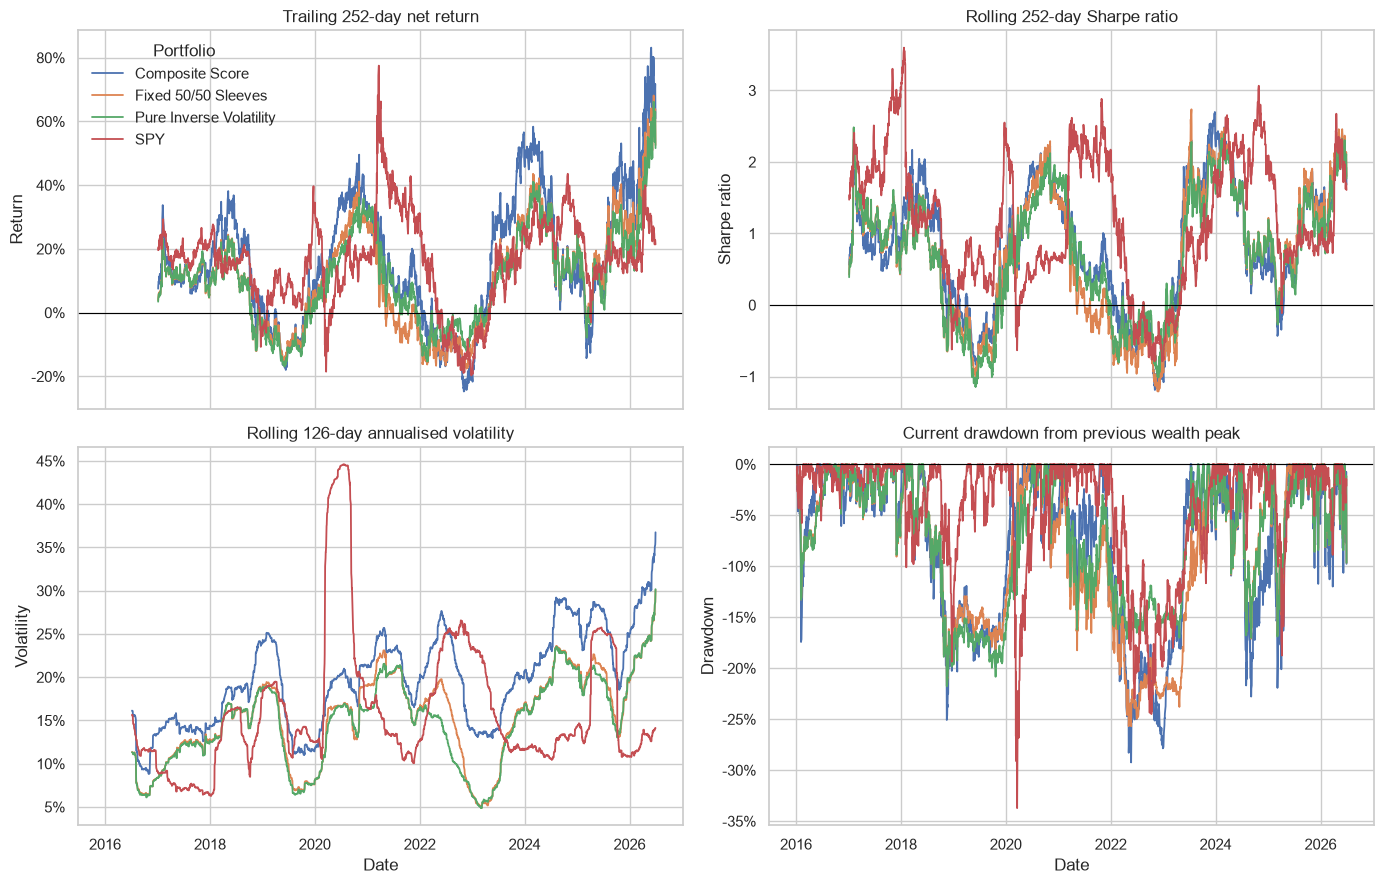

In [23]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
)

RISK_PLOT_SPECIFICATIONS = [
    (
        "trailing_return_252",
        "Trailing 252-day net return",
        "Return",
        True,
        0.0,
    ),
    (
        "rolling_sharpe_252",
        "Rolling 252-day Sharpe ratio",
        "Sharpe ratio",
        False,
        0.0,
    ),
    (
        "annualised_volatility_126",
        "Rolling 126-day annualised volatility",
        "Volatility",
        True,
        None,
    ),
    (
        "drawdown",
        "Current drawdown from previous wealth peak",
        "Drawdown",
        True,
        0.0,
    ),
]

for axis, (
    metric,
    title,
    ylabel,
    percentage_axis,
    reference_line,
) in zip(
    axes.flat,
    RISK_PLOT_SPECIFICATIONS,
):
    sns.lineplot(
        data=performance_risk_daily,
        x="date",
        y=metric,
        hue="portfolio",
        hue_order=[
            *PORTFOLIO_ORDER,
            "SPY",
        ],
        ax=axis,
        linewidth=1.3,
        legend=(axis is axes[0, 0]),
    )

    if reference_line is not None:
        axis.axhline(
            reference_line,
            color="black",
            linewidth=0.8,
        )

    axis.set_title(title)
    axis.set_xlabel("Date")
    axis.set_ylabel(ylabel)

    if percentage_axis:
        axis.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda value, _: f"{value:.0%}")
        )

axes[0, 0].legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

#### Realised and holdings-implied beta overview

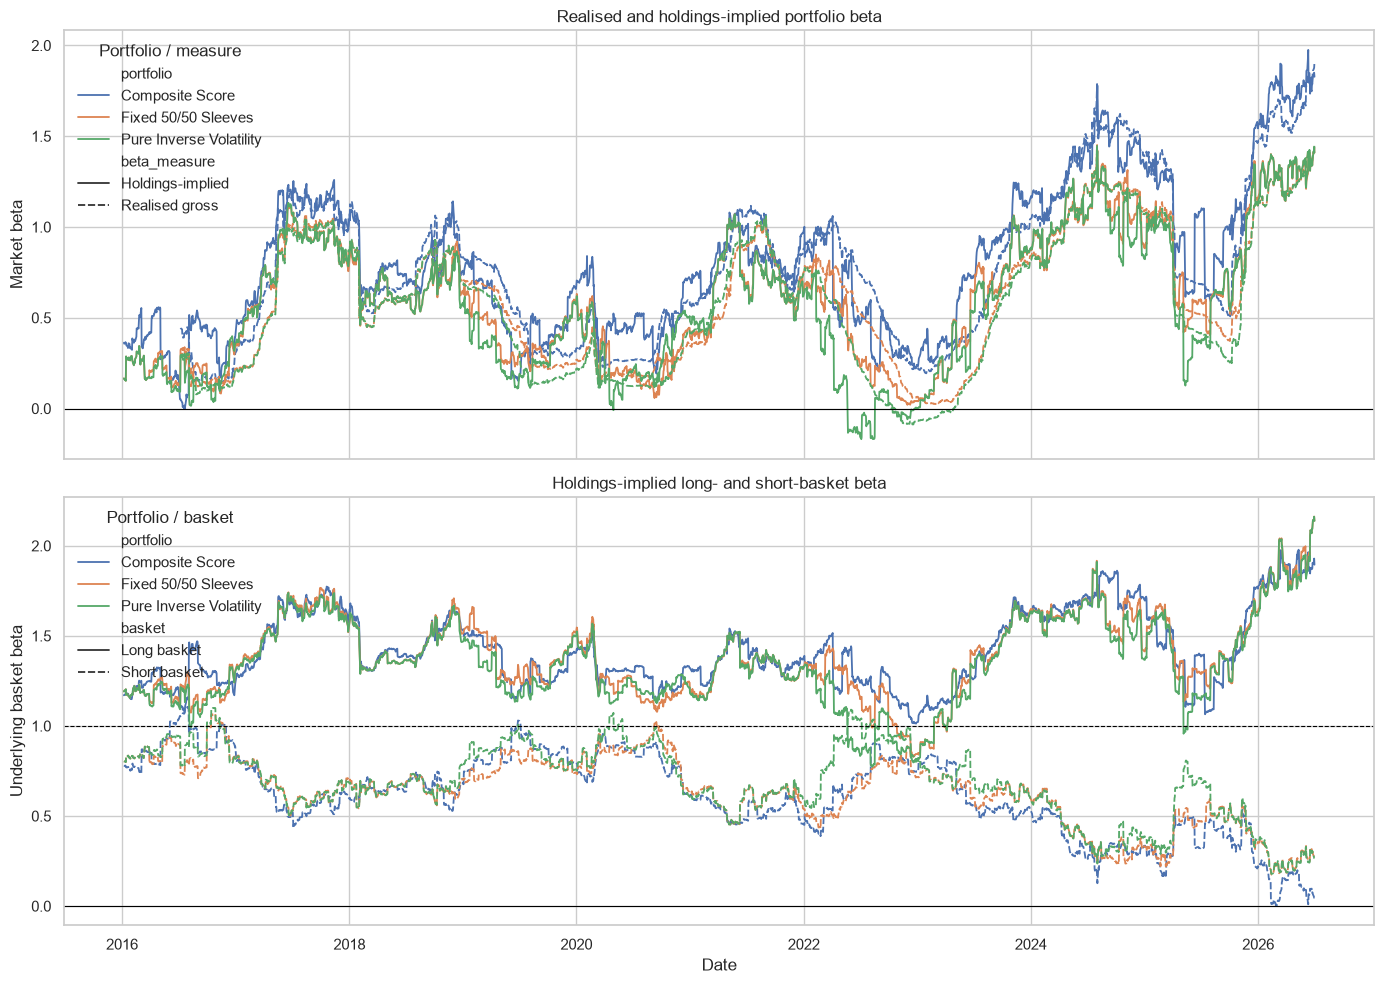

In [24]:
total_beta_plot_data = beta_state_daily.melt(
    id_vars=[
        "date",
        "portfolio",
    ],
    value_vars=[
        "holdings_market_beta",
        "realised_gross_beta_126",
    ],
    var_name="beta_measure",
    value_name="market_beta",
)

total_beta_plot_data["beta_measure"] = total_beta_plot_data["beta_measure"].replace(
    {
        "holdings_market_beta": ("Holdings-implied"),
        "realised_gross_beta_126": ("Realised gross"),
    }
)


basket_beta_plot_data = holdings_beta_daily.melt(
    id_vars=[
        "date",
        "portfolio",
    ],
    value_vars=[
        "long_basket_beta",
        "short_basket_beta",
    ],
    var_name="basket",
    value_name="market_beta",
)

basket_beta_plot_data["basket"] = basket_beta_plot_data["basket"].replace(
    {
        "long_basket_beta": "Long basket",
        "short_basket_beta": "Short basket",
    }
)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
)

sns.lineplot(
    data=total_beta_plot_data,
    x="date",
    y="market_beta",
    hue="portfolio",
    hue_order=PORTFOLIO_ORDER,
    style="beta_measure",
    ax=axes[0],
    linewidth=1.3,
)

axes[0].axhline(
    0.0,
    color="black",
    linewidth=0.8,
)

axes[0].set_title("Realised and holdings-implied portfolio beta")
axes[0].set_xlabel("")
axes[0].set_ylabel("Market beta")
axes[0].legend(
    title="Portfolio / measure",
    frameon=False,
)


sns.lineplot(
    data=basket_beta_plot_data,
    x="date",
    y="market_beta",
    hue="portfolio",
    hue_order=PORTFOLIO_ORDER,
    style="basket",
    ax=axes[1],
    linewidth=1.3,
)

axes[1].axhline(
    0.0,
    color="black",
    linewidth=0.8,
)

axes[1].axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)

axes[1].set_title("Holdings-implied long- and short-basket beta")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Underlying basket beta")
axes[1].legend(
    title="Portfolio / basket",
    frameon=False,
)

plt.tight_layout()
plt.show()

### Portfolio performance and market-risk summary

Recent performance is strong, but it has come with unusually high risk. The three portfolios returned approximately 52%–61% over the latest 252 trading days, compared with 21% for SPY, and their rolling Sharpe ratios remain between 1.68 and 1.80.

At the same time, portfolio volatility has risen to 30%–37%, versus 14% for SPY. All three strategies are also approximately 10% below their previous peaks following a sharp eight-day drawdown.

The clearest warning is market exposure. Latest holdings-implied beta ranges from 1.41 to 1.83, and realised beta from 1.45 to 1.91. Every estimate is above its own historical 90th percentile, while the close agreement between the holdings-based and realised measures suggests that this is a genuine portfolio state rather than a measurement anomaly.

This exposure comes from a large beta imbalance between the two sides of the portfolios. The long baskets currently have betas of approximately 1.90–2.14, while the securities in the short baskets have betas of only 0.05–0.27. The short books therefore provide little offset to the high-beta long books: the portfolios are roughly dollar-neutral, but far from beta-neutral.

Overall, the latest state warrants a market-risk warning. Strong recent returns should be viewed alongside elevated volatility, an active drawdown and historically high market beta. Notebook 08 identifies this condition for monitoring; whether to impose explicit beta controls remains a separate portfolio-design decision.

## 4. Security, sector and contribution concentration

This section examines whether the portfolios' exposures and recent realised outcomes are becoming dependent on a small number of securities or sectors.

Four related but distinct concepts are monitored:

1. **Position concentration** uses current absolute portfolio weights.
2. **Sector concentration** aggregates current long, short, gross and net exposure by sector.
3. **Systematic-risk concentration** uses the absolute holdings-based beta contributions, $|w_i\beta_i|$.
4. **Return-contribution concentration** uses each security's absolute gross-return contribution over the trailing 63 trading days.

For any non-negative exposure measure $x_i$, concentration is summarised by

$$
H_t=\sum_i\left(\frac{x_{i,t}}{\sum_j x_{j,t}}\right)^2,
\qquad
N_{\mathrm{eff},t}=\frac{1}{H_t}.
$$

The effective count equals the actual count when exposures are equally distributed and declines as a small number of components become dominant.

Absolute contribution measures are used because signed portfolio or sector contributions can cancel, making concentration ratios unstable. The beta-contribution diagnostic captures concentration of systematic market exposure rather than a complete covariance-based risk decomposition.

#### Construct the monitoring panel

In [43]:
# Section 4 setup: security-level exposure and contribution data

CONCENTRATION_MONITORING_WINDOW = 63
POSITION_TOLERANCE = 1e-12


# Validate the backtest-engine output.
CONCENTRATION_REQUIRED_COLUMNS = {
    "portfolio",
    "date",
    "ticker",
    "weight",
    "gross_contribution",
}

missing_concentration_columns = CONCENTRATION_REQUIRED_COLUMNS - set(
    security_daily.columns
)

if missing_concentration_columns:
    raise KeyError(
        "security_daily is missing columns: " f"{sorted(missing_concentration_columns)}"
    )


# Validate the sector source.
SECTOR_REQUIRED_COLUMNS = {
    "date",
    "ticker",
    "sector",
}

missing_sector_columns = SECTOR_REQUIRED_COLUMNS - set(factor_panel.columns)

if missing_sector_columns:
    raise KeyError(
        "factor_panel is missing columns: " f"{sorted(missing_sector_columns)}"
    )


# Confirm that security_daily has one row per
# portfolio-date-ticker.
if security_daily.duplicated(
    [
        "portfolio",
        "date",
        "ticker",
    ]
).any():
    raise ValueError("Duplicate portfolio-date-ticker rows found " "in security_daily.")


# Confirm that sector classifications do not conflict
# within the same date and ticker.
sector_key_audit = factor_panel.groupby(
    [
        "date",
        "ticker",
    ],
    sort=False,
)[
    "sector"
].nunique(dropna=False)

if sector_key_audit.gt(1).any():
    raise ValueError("Conflicting sector values found for the same " "date and ticker.")


# Build the date-specific sector lookup.
security_sector_panel = factor_panel[
    [
        "date",
        "ticker",
        "sector",
    ]
].drop_duplicates(
    [
        "date",
        "ticker",
    ]
)


# Use security_daily as the source of both portfolio
# weights and exact backtest-engine contributions.
concentration_security_daily = (
    security_daily.loc[security_daily["portfolio"].isin(PORTFOLIO_ORDER)]
    .merge(
        security_sector_panel,
        on=[
            "date",
            "ticker",
        ],
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "portfolio",
            "ticker",
            "date",
        ]
    )
    .reset_index(drop=True)
)


missing_portfolios = set(PORTFOLIO_ORDER) - set(
    concentration_security_daily["portfolio"].unique()
)

if missing_portfolios:
    raise ValueError(
        "security_daily contains no observations for: " f"{sorted(missing_portfolios)}"
    )


# Current post-trade weights are used for exposure
# and position-concentration monitoring.
concentration_security_daily["absolute_weight"] = concentration_security_daily[
    "weight"
].abs()

concentration_security_daily["long_weight"] = concentration_security_daily[
    "weight"
].clip(lower=0.0)

concentration_security_daily["short_weight"] = -concentration_security_daily[
    "weight"
].clip(upper=0.0)


# Audit sector coverage for actively held positions.
held_position_mask = concentration_security_daily["absolute_weight"].gt(
    POSITION_TOLERANCE
)

sector_coverage_audit = (
    concentration_security_daily.loc[held_position_mask]
    .assign(
        sector_covered_weight=lambda data: (
            data["absolute_weight"].where(
                data["sector"].notna(),
                0.0,
            )
        )
    )
    .groupby(
        [
            "portfolio",
            "date",
        ],
        sort=False,
    )
    .agg(
        held_gross_weight=(
            "absolute_weight",
            "sum",
        ),
        sector_covered_weight=(
            "sector_covered_weight",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

sector_coverage_audit["sector_coverage"] = np.where(
    sector_coverage_audit["held_gross_weight"].gt(POSITION_TOLERANCE),
    (
        sector_coverage_audit["sector_covered_weight"]
        / sector_coverage_audit["held_gross_weight"]
    ),
    1.0,
)

sector_coverage_summary = (
    sector_coverage_audit.groupby(
        "portfolio",
        sort=False,
    )
    .agg(
        minimum_sector_coverage=(
            "sector_coverage",
            "min",
        ),
        latest_sector_coverage=(
            "sector_coverage",
            "last",
        ),
    )
    .reindex(PORTFOLIO_ORDER)
)

display(sector_coverage_summary.round(4))

if (
    sector_coverage_summary["minimum_sector_coverage"]
    .lt(1.0 - MONITORING_TOLERANCE)
    .any()
):
    raise ValueError("Some held portfolio weight lacks sector metadata.")

,minimum_sector_coverage,latest_sector_coverage
portfolio,,
Composite Score,1.0,1.0
Fixed 50/50 Sleeves,1.0,1.0
Pure Inverse Volatility,1.0,1.0


#### Position concentration

In [34]:
def calculate_concentration_statistics(
    values: pd.Series,
) -> dict:
    values = pd.Series(values).dropna().astype(float)

    values = values.loc[values.gt(POSITION_TOLERANCE)]

    total = values.sum()

    if values.empty or total <= 0.0:
        return {
            "count": 0,
            "effective_count": np.nan,
            "largest_share": np.nan,
            "top_three_share": np.nan,
            "top_five_share": np.nan,
        }

    shares = values / total

    return {
        "count": len(shares),
        "effective_count": (1.0 / shares.pow(2).sum()),
        "largest_share": shares.max(),
        "top_three_share": (shares.nlargest(3).sum()),
        "top_five_share": (shares.nlargest(5).sum()),
    }


position_concentration_rows = []

for (
    portfolio_name,
    date,
), group in concentration_security_daily.groupby(
    [
        "portfolio",
        "date",
    ],
    sort=False,
):
    gross_statistics = calculate_concentration_statistics(group["absolute_weight"])

    long_statistics = calculate_concentration_statistics(group["long_weight"])

    short_statistics = calculate_concentration_statistics(group["short_weight"])

    position_concentration_rows.append(
        {
            "portfolio": portfolio_name,
            "date": date,
            "gross_exposure": (group["absolute_weight"].sum()),
            "held_position_count": (gross_statistics["count"]),
            "effective_position_count": (gross_statistics["effective_count"]),
            "largest_absolute_weight": (group["absolute_weight"].max()),
            "largest_position_gross_share": (gross_statistics["largest_share"]),
            "top_five_position_gross_share": (gross_statistics["top_five_share"]),
            "effective_long_position_count": (long_statistics["effective_count"]),
            "effective_short_position_count": (short_statistics["effective_count"]),
            "largest_long_book_share": (long_statistics["largest_share"]),
            "largest_short_book_share": (short_statistics["largest_share"]),
        }
    )


position_concentration_daily = (
    pd.DataFrame(position_concentration_rows)
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

#### Sector and systematic-beta concentration

In [35]:
sector_exposure_daily = (
    concentration_security_daily.groupby(
        [
            "portfolio",
            "date",
            "sector",
        ],
        sort=False,
        observed=True,
    )
    .agg(
        long_exposure=(
            "long_weight",
            "sum",
        ),
        short_exposure=(
            "short_weight",
            "sum",
        ),
    )
    .reset_index()
)

sector_exposure_daily["gross_exposure"] = (
    sector_exposure_daily["long_exposure"] + sector_exposure_daily["short_exposure"]
)

sector_exposure_daily["net_exposure"] = (
    sector_exposure_daily["long_exposure"] - sector_exposure_daily["short_exposure"]
)


sector_concentration_rows = []

for (
    portfolio_name,
    date,
), group in sector_exposure_daily.groupby(
    [
        "portfolio",
        "date",
    ],
    sort=False,
):
    sector_statistics = calculate_concentration_statistics(group["gross_exposure"])

    sector_concentration_rows.append(
        {
            "portfolio": portfolio_name,
            "date": date,
            "held_sector_count": (sector_statistics["count"]),
            "effective_sector_count": (sector_statistics["effective_count"]),
            "largest_sector_gross_share": (sector_statistics["largest_share"]),
            "top_three_sector_gross_share": (sector_statistics["top_three_share"]),
            "largest_absolute_sector_net_exposure": (group["net_exposure"].abs().max()),
        }
    )


sector_concentration_daily = (
    pd.DataFrame(sector_concentration_rows)
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)


beta_concentration_input = holdings_with_beta.assign(
    absolute_beta_contribution=lambda data: (data["market_beta_contribution"].abs())
)


beta_concentration_rows = []

for (
    portfolio_name,
    date,
), group in beta_concentration_input.groupby(
    [
        "portfolio",
        "date",
    ],
    sort=False,
):
    beta_statistics = calculate_concentration_statistics(
        group["absolute_beta_contribution"]
    )

    beta_concentration_rows.append(
        {
            "portfolio": portfolio_name,
            "date": date,
            "effective_beta_contributor_count": (beta_statistics["effective_count"]),
            "largest_absolute_beta_contribution_share": (
                beta_statistics["largest_share"]
            ),
            "top_five_absolute_beta_contribution_share": (
                beta_statistics["top_five_share"]
            ),
        }
    )


beta_concentration_daily = (
    pd.DataFrame(beta_concentration_rows)
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

#### Trailing contribution concentration

In [36]:
concentration_security_daily["absolute_gross_contribution"] = (
    concentration_security_daily["gross_contribution"].abs()
)


security_contribution_groups = concentration_security_daily.groupby(
    [
        "portfolio",
        "ticker",
    ],
    sort=False,
)

concentration_security_daily[
    "rolling_gross_contribution_63"
] = security_contribution_groups["gross_contribution"].transform(
    lambda values: values.rolling(
        CONCENTRATION_MONITORING_WINDOW,
        min_periods=(CONCENTRATION_MONITORING_WINDOW),
    ).sum()
)

concentration_security_daily[
    "rolling_absolute_gross_contribution_63"
] = security_contribution_groups["absolute_gross_contribution"].transform(
    lambda values: values.rolling(
        CONCENTRATION_MONITORING_WINDOW,
        min_periods=(CONCENTRATION_MONITORING_WINDOW),
    ).sum()
)


security_contribution_concentration_rows = []

for (
    portfolio_name,
    date,
), group in concentration_security_daily.groupby(
    [
        "portfolio",
        "date",
    ],
    sort=False,
):
    contribution_statistics = calculate_concentration_statistics(
        group["rolling_absolute_gross_contribution_63"]
    )

    valid_contributions = group.dropna(
        subset=[
            "rolling_absolute_gross_contribution_63",
        ]
    )

    if valid_contributions.empty:
        largest_contributor = pd.NA
    else:
        largest_contributor = valid_contributions.loc[
            valid_contributions["rolling_absolute_gross_contribution_63"].idxmax(),
            "ticker",
        ]

    security_contribution_concentration_rows.append(
        {
            "portfolio": portfolio_name,
            "date": date,
            "effective_contributor_count_63": (
                contribution_statistics["effective_count"]
            ),
            "largest_contributor_share_63": (contribution_statistics["largest_share"]),
            "top_five_contributor_share_63": (
                contribution_statistics["top_five_share"]
            ),
            "largest_contributor_63": (largest_contributor),
        }
    )


security_contribution_concentration_daily = pd.DataFrame(
    security_contribution_concentration_rows
)


sector_contribution_daily = (
    concentration_security_daily.groupby(
        [
            "portfolio",
            "date",
            "sector",
        ],
        sort=False,
        observed=True,
    )
    .agg(
        gross_contribution=(
            "gross_contribution",
            "sum",
        ),
        absolute_gross_contribution=(
            "absolute_gross_contribution",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "portfolio",
            "sector",
            "date",
        ]
    )
    .reset_index(drop=True)
)


sector_contribution_groups = sector_contribution_daily.groupby(
    [
        "portfolio",
        "sector",
    ],
    sort=False,
)

sector_contribution_daily["rolling_gross_contribution_63"] = sector_contribution_groups[
    "gross_contribution"
].transform(
    lambda values: values.rolling(
        CONCENTRATION_MONITORING_WINDOW,
        min_periods=(CONCENTRATION_MONITORING_WINDOW),
    ).sum()
)

sector_contribution_daily[
    "rolling_absolute_gross_contribution_63"
] = sector_contribution_groups["absolute_gross_contribution"].transform(
    lambda values: values.rolling(
        CONCENTRATION_MONITORING_WINDOW,
        min_periods=(CONCENTRATION_MONITORING_WINDOW),
    ).sum()
)


sector_contribution_concentration_rows = []

for (
    portfolio_name,
    date,
), group in sector_contribution_daily.groupby(
    [
        "portfolio",
        "date",
    ],
    sort=False,
):
    contribution_statistics = calculate_concentration_statistics(
        group["rolling_absolute_gross_contribution_63"]
    )

    valid_contributions = group.dropna(
        subset=[
            "rolling_absolute_gross_contribution_63",
        ]
    )

    if valid_contributions.empty:
        largest_sector = pd.NA
    else:
        largest_sector = valid_contributions.loc[
            valid_contributions["rolling_absolute_gross_contribution_63"].idxmax(),
            "sector",
        ]

    sector_contribution_concentration_rows.append(
        {
            "portfolio": portfolio_name,
            "date": date,
            "effective_contribution_sector_count_63": (
                contribution_statistics["effective_count"]
            ),
            "largest_contribution_sector_share_63": (
                contribution_statistics["largest_share"]
            ),
            "largest_contribution_sector_63": (largest_sector),
        }
    )


sector_contribution_concentration_daily = pd.DataFrame(
    sector_contribution_concentration_rows
)

#### Consolidate the daily monitoring state

In [37]:
concentration_state_daily = (
    position_concentration_daily.merge(
        sector_concentration_daily,
        on=[
            "portfolio",
            "date",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        beta_concentration_daily,
        on=[
            "portfolio",
            "date",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        security_contribution_concentration_daily,
        on=[
            "portfolio",
            "date",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        sector_contribution_concentration_daily,
        on=[
            "portfolio",
            "date",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)


latest_concentration_state = (
    concentration_state_daily.groupby(
        "portfolio",
        sort=False,
    )
    .tail(1)
    .set_index("portfolio")
    .reindex(PORTFOLIO_ORDER)[
        [
            "date",
            "held_position_count",
            "effective_position_count",
            "largest_absolute_weight",
            "largest_position_gross_share",
            "top_five_position_gross_share",
            "effective_long_position_count",
            "effective_short_position_count",
            "effective_sector_count",
            "largest_sector_gross_share",
            "largest_absolute_sector_net_exposure",
            "effective_beta_contributor_count",
            "largest_absolute_beta_contribution_share",
            "effective_contributor_count_63",
            "largest_contributor_share_63",
            "top_five_contributor_share_63",
            "largest_contributor_63",
            "effective_contribution_sector_count_63",
            "largest_contribution_sector_share_63",
            "largest_contribution_sector_63",
        ]
    ]
)

display(latest_concentration_state.round(4))

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\2711799660.py:81: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_concentration_state.round(4))


,date,held_position_count,effective_position_count,largest_absolute_weight,largest_position_gross_share,top_five_position_gross_share,effective_long_position_count,effective_short_position_count,effective_sector_count,largest_sector_gross_share,largest_absolute_sector_net_exposure,effective_beta_contributor_count,largest_absolute_beta_contribution_share,effective_contributor_count_63,largest_contributor_share_63,top_five_contributor_share_63,largest_contributor_63,effective_contribution_sector_count_63,largest_contribution_sector_share_63,largest_contribution_sector_63
portfolio,,,,,,,,,,,,,,,,,,,,
Composite Score,2026-07-01,40,39.7621,0.0592,0.0303,0.1404,19.8368,19.9310,5.3959,0.3474,0.6794,20.3572,0.0805,31.8992,0.0721,0.2906,MU,3.2127,0.5272,Information Technology
Fixed 50/50 Sleeves,2026-07-01,51,45.3945,0.0552,0.0365,0.1771,18.2341,29.9296,5.8177,0.3308,0.4491,19.9103,0.0884,28.8363,0.0859,0.3467,MU,3.2069,0.5273,Information Technology
Pure Inverse Volatility,2026-07-01,61,45.4281,0.0552,0.0365,0.1770,18.2443,29.9605,5.8151,0.3309,0.4488,19.9201,0.0884,29.6973,0.0844,0.3407,MU,3.1453,0.5344,Information Technology


#### Compare the latest values with history

In [ ]:
CONCENTRATION_METRICS = {
    "effective_position_count": (
        "Effective positions",
        "Higher means more diversified",
    ),
    "top_five_position_gross_share": (
        "Top-five position share",
        "Higher means more concentrated",
    ),
    "effective_sector_count": (
        "Effective sectors",
        "Higher means more diversified",
    ),
    "largest_sector_gross_share": (
        "Largest sector gross share",
        "Higher means more concentrated",
    ),
    "largest_absolute_sector_net_exposure": (
        "Largest absolute sector net exposure",
        "Higher means greater directional concentration",
    ),
    "effective_beta_contributor_count": (
        "Effective beta contributors",
        "Higher means more diversified",
    ),
    "top_five_absolute_beta_contribution_share": (
        "Top-five absolute beta-contribution share",
        "Higher means more concentrated",
    ),
    "effective_contributor_count_63": (
        "Effective 63-day contributors",
        "Higher means more diversified",
    ),
    "top_five_contributor_share_63": (
        "Top-five 63-day contributor share",
        "Higher means more concentrated",
    ),
    "effective_contribution_sector_count_63": (
        "Effective 63-day contribution sectors",
        "Higher means more diversified",
    ),
}


concentration_history_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = concentration_state_daily.loc[
        concentration_state_daily["portfolio"].eq(portfolio_name)
    ].sort_values("date")

    latest_row = portfolio_data.iloc[-1]

    for metric, (
        display_name,
        interpretation,
    ) in CONCENTRATION_METRICS.items():
        history = portfolio_data[metric].dropna()

        latest_value = latest_row[metric]

        concentration_history_rows.append(
            {
                "portfolio": portfolio_name,
                "metric": display_name,
                "latest_value": latest_value,
                "historical_tenth_percentile": (history.quantile(0.10)),
                "historical_median": (history.median()),
                "historical_ninetieth_percentile": (history.quantile(0.90)),
                "latest_historical_percentile": (
                    history.le(latest_value).mean()
                    if (len(history) > 0 and pd.notna(latest_value))
                    else np.nan
                ),
                "interpretation": interpretation,
            }
        )


concentration_history_summary = pd.DataFrame(concentration_history_rows).set_index(
    [
        "portfolio",
        "metric",
    ]
)

display(concentration_history_summary.round(4))

latest_value  historical_tenth_percentile  historical_median  \
portfolio               metric                                                                                                    
Composite Score         Effective positions                             39.7621                      39.7422            39.9130   
                        Top-five position share                          0.1404                       0.1285             0.1347   
                        Effective sectors                                5.3959                       5.5070             6.5466   
                        Largest sector gross share                       0.3474                       0.1974             0.2554   
                        Largest absolute sector net exposure             0.6794                       0.2652             0.4000   
                        Effective beta contributors                     20.3572                      23.5243            31.1388   
                        Top-five absolute beta-contribution share        0.3798                       0.2023             0.2445   
                        Effective 63-day contributors                   31.8992                      35.3900            39.2193   
                        Top-five 63-day contributor share                0.2906                       0.1986             0.2272   
                        Effective 63-day contribution sectors            3.2127                       4.2169             5.3916   
Fixed 50/50 Sleeves     Effective positions                             45.3945                      38.9308            47.9816   
                        Top-five position share                          0.1771                       0.1364             0.1568   
                        Effective sectors                                5.8177                       5.7559             6.6326   
                        Largest sector gross share                       0.3308                       0.1919             0.2568   
                        Largest absolute sector net exposure             0.4491                       0.1750             0.3000   
                        Effective beta contributors                     19.9103                      23.4711            31.7123   
                        Top-five absolute beta-contribution share        0.4192                       0.2206             0.2784   
                        Effective 63-day contributors                   28.8363                      34.2103            41.1997   
                        Top-five 63-day contributor share                0.3467                       0.2014             0.2475   
                        Effective 63-day contribution sectors            3.2069                       4.1588             5.2935   
Pure Inverse Volatility Effective positions                             45.4281                      43.2161            50.5716   
                        Top-five position share                          0.1770                       0.1354             0.1512   
                        Effective sectors                                5.8151                       5.8370             6.7270   
                        Largest sector gross share                       0.3309                       0.1900             0.2517   
                        Largest absolute sector net exposure             0.4488                       0.1534             0.2864   
                        Effective beta contributors                     19.9201                      25.7367            34.5061   
                        Top-five absolute beta-contribution share        0.4191                       0.2112             0.2645   
                        Effective 63-day contributors                   29.6973                      35.6668            44.1662   
                        Top-five 63-day contributor share                0.3407                       0.1871             0.2347   
      

#### Latest positions, sectors and contributors

In [39]:
latest_concentration_dates = (
    concentration_state_daily.groupby(
        "portfolio",
        sort=False,
    )["date"]
    .max()
    .rename("latest_date")
    .reset_index()
)


latest_position_detail = (
    concentration_security_daily.merge(
        latest_concentration_dates,
        on="portfolio",
        how="inner",
        validate="many_to_one",
    )
    .loc[
        lambda data: (
            data["date"].eq(data["latest_date"])
            & data["absolute_weight"].gt(POSITION_TOLERANCE)
        )
    ]
    .merge(
        position_concentration_daily[
            [
                "portfolio",
                "date",
                "gross_exposure",
            ]
        ],
        on=[
            "portfolio",
            "date",
        ],
        how="left",
        validate="many_to_one",
    )
    .assign(
        gross_position_share=lambda data: (
            data["absolute_weight"] / data["gross_exposure"]
        )
    )
    .sort_values(
        [
            "portfolio",
            "absolute_weight",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "portfolio",
        sort=False,
    )
    .head(10)[
        [
            "portfolio",
            "date",
            "ticker",
            "sector",
            "weight",
            "absolute_weight",
            "gross_position_share",
        ]
    ]
)


latest_sector_exposure = (
    sector_exposure_daily.merge(
        latest_concentration_dates,
        on="portfolio",
        how="inner",
        validate="many_to_one",
    )
    .loc[lambda data: data["date"].eq(data["latest_date"])]
    .assign(
        sector_gross_share=lambda data: (
            data["gross_exposure"]
            / data.groupby("portfolio")["gross_exposure"].transform("sum")
        )
    )
    .sort_values(
        [
            "portfolio",
            "gross_exposure",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


latest_security_contributors_63 = (
    concentration_security_daily.merge(
        latest_concentration_dates,
        on="portfolio",
        how="inner",
        validate="many_to_one",
    )
    .loc[lambda data: data["date"].eq(data["latest_date"])]
    .dropna(
        subset=[
            "rolling_absolute_gross_contribution_63",
        ]
    )
    .assign(
        absolute_contribution_share_63=lambda data: (
            data["rolling_absolute_gross_contribution_63"]
            / data.groupby("portfolio")[
                "rolling_absolute_gross_contribution_63"
            ].transform("sum")
        )
    )
    .sort_values(
        [
            "portfolio",
            "rolling_absolute_gross_contribution_63",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "portfolio",
        sort=False,
    )
    .head(10)[
        [
            "portfolio",
            "date",
            "ticker",
            "sector",
            "rolling_gross_contribution_63",
            "rolling_absolute_gross_contribution_63",
            "absolute_contribution_share_63",
        ]
    ]
)


latest_sector_contributors_63 = (
    sector_contribution_daily.merge(
        latest_concentration_dates,
        on="portfolio",
        how="inner",
        validate="many_to_one",
    )
    .loc[lambda data: data["date"].eq(data["latest_date"])]
    .dropna(
        subset=[
            "rolling_absolute_gross_contribution_63",
        ]
    )
    .assign(
        absolute_contribution_share_63=lambda data: (
            data["rolling_absolute_gross_contribution_63"]
            / data.groupby("portfolio")[
                "rolling_absolute_gross_contribution_63"
            ].transform("sum")
        )
    )
    .sort_values(
        [
            "portfolio",
            "rolling_absolute_gross_contribution_63",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "portfolio",
        sort=False,
    )
    .head(5)[
        [
            "portfolio",
            "date",
            "sector",
            "rolling_gross_contribution_63",
            "rolling_absolute_gross_contribution_63",
            "absolute_contribution_share_63",
        ]
    ]
)


display(latest_position_detail.round(4))

display(
    latest_sector_exposure[
        [
            "portfolio",
            "date",
            "sector",
            "long_exposure",
            "short_exposure",
            "gross_exposure",
            "net_exposure",
            "sector_gross_share",
        ]
    ].round(4)
)

display(latest_security_contributors_63.round(4))

display(latest_sector_contributors_63.round(4))

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\828323567.py:197: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_position_detail.round(4))


,portfolio,date,ticker,sector,weight,absolute_weight,gross_position_share
13,Composite Score,2026-07-01,GEV,Industrials,0.0592,0.0592,0.0303
1,Composite Score,2026-07-01,AMAT,Information Technology,0.0563,0.0563,0.0288
38,Composite Score,2026-07-01,V,Financials,-0.0534,0.0534,0.0273
6,Composite Score,2026-07-01,CAT,Industrials,0.0534,0.0534,0.0273
20,Composite Score,2026-07-01,LRCX,Information Technology,0.0524,0.0524,0.0268
21,Composite Score,2026-07-01,MA,Financials,-0.0523,0.0523,0.0267
2,Composite Score,2026-07-01,AMD,Information Technology,0.0519,0.0519,0.0265
25,Composite Score,2026-07-01,MU,Information Technology,0.0516,0.0516,0.0264
36,Composite Score,2026-07-01,TSLA,Consumer Discretionary,0.0513,0.0513,0.0262
0,Composite Score,2026-07-01,ABT,Health Care,-0.0513,0.0513,0.0262


C:\Users\39521\AppData\Local\Temp\ipykernel_12180\828323567.py:211: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(4)


,portfolio,date,sector,long_exposure,short_exposure,gross_exposure,net_exposure,sector_gross_share
2634,Composite Score,2026-07-01,Information Technology,0.6794,0.0000,0.6794,0.6794,0.3474
18444,Composite Score,2026-07-01,Consumer Staples,0.0000,0.2886,0.2886,-0.2886,0.1476
21079,Composite Score,2026-07-01,Communication Services,0.0983,0.1327,0.2310,-0.0344,0.1181
13174,Composite Score,2026-07-01,Financials,0.0000,0.2070,0.2070,-0.2070,0.1058
15809,Composite Score,2026-07-01,Industrials,0.1583,0.0000,0.1583,0.1583,0.0809
5269,Composite Score,2026-07-01,Health Care,0.0000,0.1449,0.1449,-0.1449,0.0741
26349,Composite Score,2026-07-01,Utilities,0.0000,0.0990,0.0990,-0.0990,0.0506
10539,Composite Score,2026-07-01,Consumer Discretionary,0.0513,0.0464,0.0978,0.0049,0.0500
28984,Composite Score,2026-07-01,Materials,0.0000,0.0500,0.0500,-0.0500,0.0256
7904,Composite Score,2026-07-01,Real Estate,0.0000,0.0000,0.0000,0.0000,0.0000


C:\Users\39521\AppData\Local\Temp\ipykernel_12180\828323567.py:214: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_security_contributors_63.round(4))


,portfolio,date,ticker,sector,rolling_gross_contribution_63,rolling_absolute_gross_contribution_63,absolute_contribution_share_63
177123,Composite Score,2026-07-01,MU,Information Technology,0.0721,0.1783,0.0721
121788,Composite Score,2026-07-01,INTC,Information Technology,0.0761,0.1680,0.0680
18444,Composite Score,2026-07-01,AMD,Information Technology,0.0650,0.1470,0.0595
148138,Composite Score,2026-07-01,LRCX,Information Technology,0.0367,0.1153,0.0467
15809,Composite Score,2026-07-01,AMAT,Information Technology,0.0392,0.1097,0.0444
192933,Composite Score,2026-07-01,ORCL,Information Technology,0.0042,0.0995,0.0402
100696,Composite Score,2026-07-01,GEV,Industrials,0.0180,0.0831,0.0336
202282,Composite Score,2026-07-01,PLTR,Information Technology,-0.0022,0.0813,0.0329
28984,Composite Score,2026-07-01,AVGO,Information Technology,0.0123,0.0794,0.0321
187663,Composite Score,2026-07-01,NOW,Information Technology,0.0156,0.0786,0.0318


C:\Users\39521\AppData\Local\Temp\ipykernel_12180\828323567.py:216: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_sector_contributors_63.round(4))


,portfolio,date,sector,rolling_gross_contribution_63,rolling_absolute_gross_contribution_63,absolute_contribution_share_63
21079,Composite Score,2026-07-01,Information Technology,0.3187,1.3028,0.5272
18444,Composite Score,2026-07-01,Industrials,0.0529,0.2547,0.1031
2634,Composite Score,2026-07-01,Communication Services,0.0312,0.1873,0.0758
7904,Composite Score,2026-07-01,Consumer Staples,-0.0112,0.1825,0.0739
13174,Composite Score,2026-07-01,Financials,0.0198,0.1798,0.0727
50064,Fixed 50/50 Sleeves,2026-07-01,Information Technology,0.3065,1.0794,0.5273
47429,Fixed 50/50 Sleeves,2026-07-01,Industrials,0.0362,0.2487,0.1215
42159,Fixed 50/50 Sleeves,2026-07-01,Financials,-0.0023,0.1479,0.0722
44794,Fixed 50/50 Sleeves,2026-07-01,Health Care,0.0084,0.1292,0.0631
31619,Fixed 50/50 Sleeves,2026-07-01,Communication Services,0.0231,0.1223,0.0598


#### Concentration history

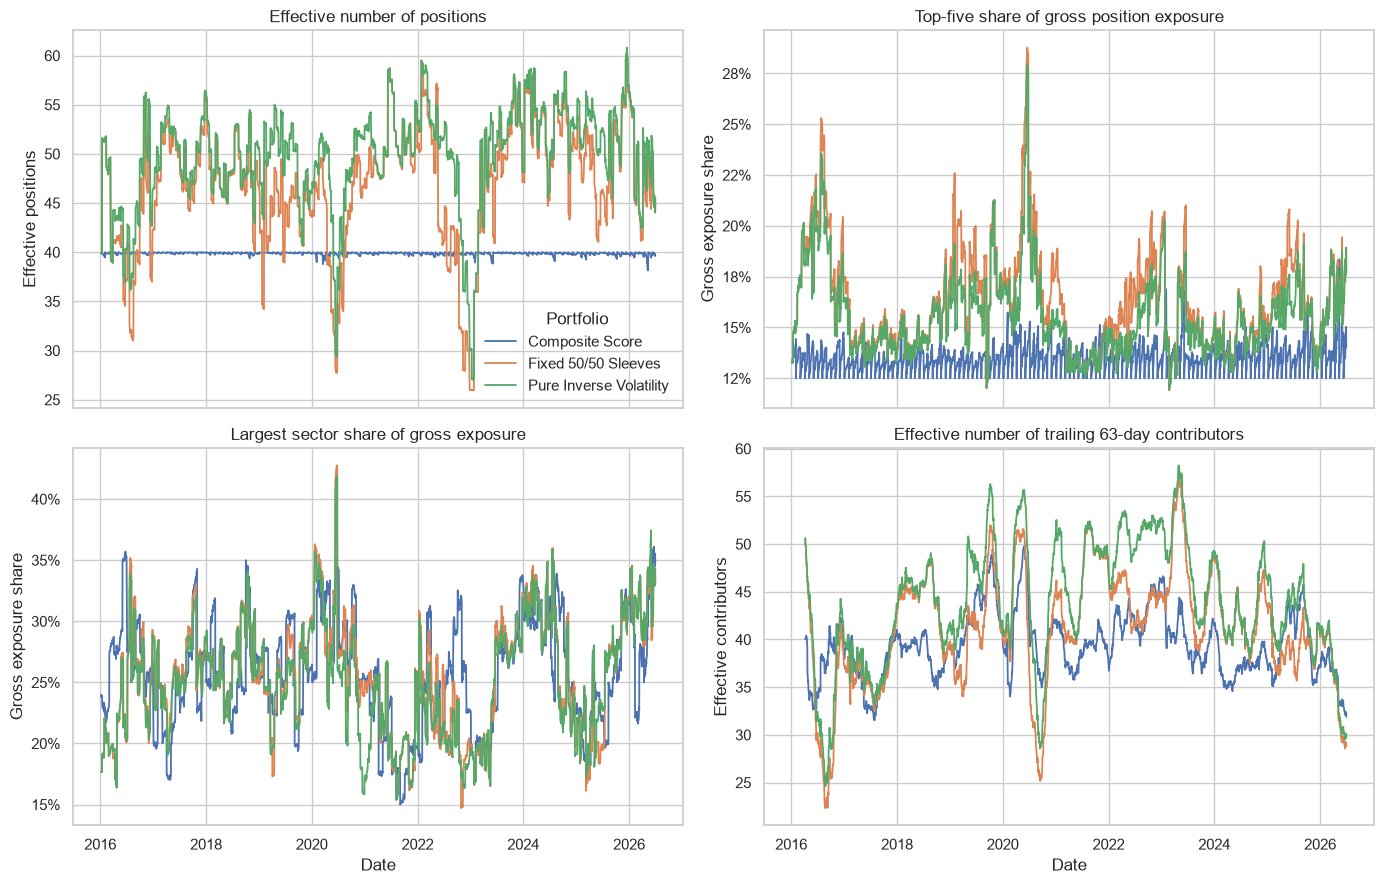

In [40]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
)

CONCENTRATION_PLOT_SPECIFICATIONS = [
    (
        "effective_position_count",
        "Effective number of positions",
        "Effective positions",
        False,
    ),
    (
        "top_five_position_gross_share",
        "Top-five share of gross position exposure",
        "Gross exposure share",
        True,
    ),
    (
        "largest_sector_gross_share",
        "Largest sector share of gross exposure",
        "Gross exposure share",
        True,
    ),
    (
        "effective_contributor_count_63",
        "Effective number of trailing 63-day contributors",
        "Effective contributors",
        False,
    ),
]

for axis, (
    metric,
    title,
    ylabel,
    percentage_axis,
) in zip(
    axes.flat,
    CONCENTRATION_PLOT_SPECIFICATIONS,
):
    sns.lineplot(
        data=concentration_state_daily,
        x="date",
        y=metric,
        hue="portfolio",
        hue_order=PORTFOLIO_ORDER,
        ax=axis,
        linewidth=1.3,
        legend=(axis is axes[0, 0]),
    )

    axis.set_title(title)
    axis.set_xlabel("Date")
    axis.set_ylabel(ylabel)

    if percentage_axis:
        axis.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda value, _: f"{value:.0%}")
        )

axes[0, 0].legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

#### Latest sector exposure heatmaps

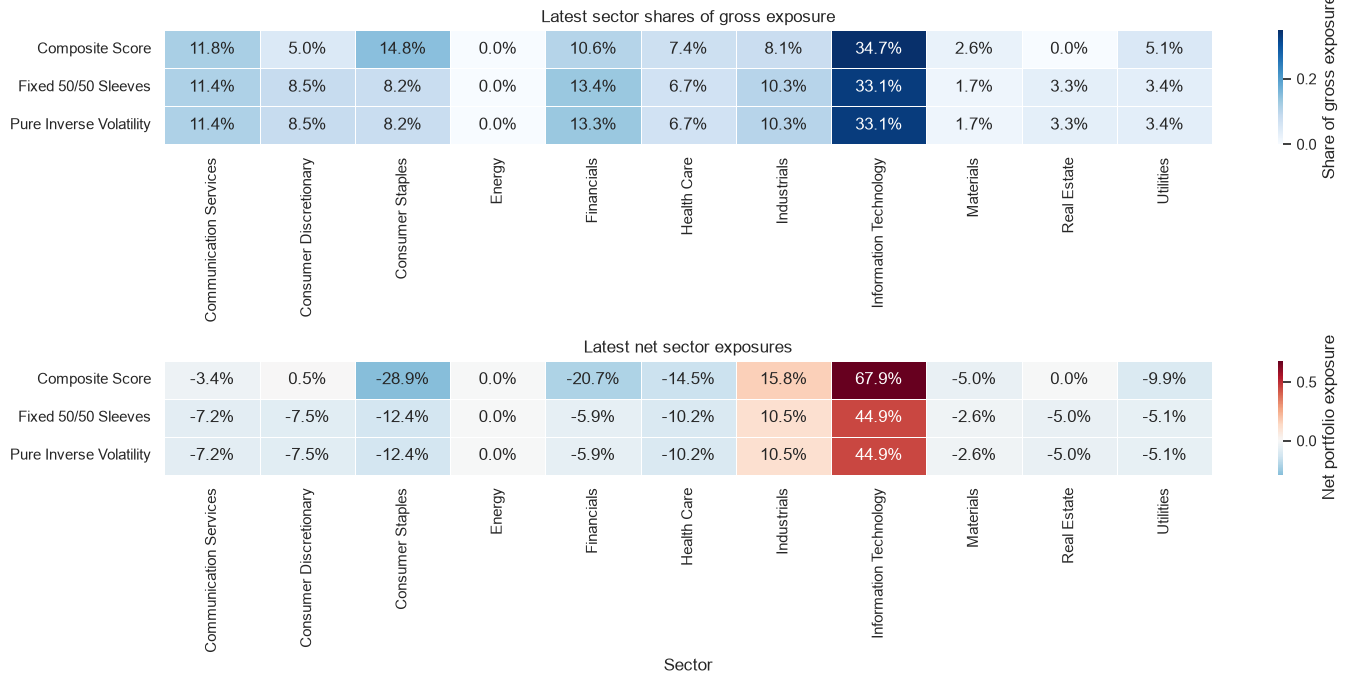

In [41]:
latest_sector_gross_matrix = latest_sector_exposure.pivot(
    index="portfolio",
    columns="sector",
    values="sector_gross_share",
).reindex(PORTFOLIO_ORDER)

latest_sector_net_matrix = latest_sector_exposure.pivot(
    index="portfolio",
    columns="sector",
    values="net_exposure",
).reindex(
    index=PORTFOLIO_ORDER,
    columns=(latest_sector_gross_matrix.columns),
)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 7),
)

sns.heatmap(
    latest_sector_gross_matrix,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={
        "label": "Share of gross exposure",
    },
    ax=axes[0],
)

axes[0].set_title("Latest sector shares of gross exposure")
axes[0].set_xlabel("")
axes[0].set_ylabel("")


sns.heatmap(
    latest_sector_net_matrix,
    annot=True,
    fmt=".1%",
    cmap="RdBu_r",
    center=0.0,
    linewidths=0.5,
    cbar_kws={
        "label": "Net portfolio exposure",
    },
    ax=axes[1],
)

axes[1].set_title("Latest net sector exposures")
axes[1].set_xlabel("Sector")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Concentration summary

The portfolios remain reasonably diversified by individual position weight. Composite Score holds 40 securities with an effective count of 39.8, while the two sleeve portfolios have effective counts of approximately 45. Their top-five position shares are moderately elevated but remain within their historical ranges.

The more important concentration is at the sector and risk-exposure levels. Information Technology currently represents 33%–35% of gross exposure and produces net exposures of 67.9% for Composite Score and approximately 44.9% for both sleeve portfolios. These values are near the upper end of their histories. The portfolios are therefore broadly diversified across names, but heavily dependent on a long-IT versus short-defensive-sector allocation.

Systematic market exposure is also concentrated. Only about 20 effective beta contributors remain in each portfolio, close to the bottom of their historical distributions, while the five largest absolute beta contributions account for 38%–42% of the total. This helps explain Section 3's elevated portfolio beta: nominal weight diversification is not translating into beta diversification.

Recent realised contributions show the same pattern. The effective number of trailing 63-day security contributors has fallen to 29–32, and the top five contributors account for 29%–35% of absolute contribution—the highest shares observed historically. At sector level, the effective contributor count is only about 3.2, with Information Technology accounting for approximately 53% of trailing absolute contribution. MU is the largest individual contributor across all three portfolios.

Overall, the latest state warrants a concentration warning. The portfolios are not dominated by a single oversized position, but their market exposure and recent outcomes are unusually dependent on a relatively small group of Information Technology holdings. This concentration provides an important link between the elevated beta, high volatility and strong recent performance identified in Section 3.

## 5. Implementation Health

This section monitors whether the selected portfolio implementations remain operationally healthy.

The diagnostics cover:

1. realised turnover and transaction-cost drag;
2. trading frequency and maximum trade size;
3. missing-return exposure;
4. liquidity coverage; and
5. implied portfolio capacity using lagged median dollar volume.

Capacity is estimated at a 1% participation rate:

$$
\text{capacity}_{i,t}
=
\frac{0.01 \times \text{lagged median dollar volume}_{i,t}}
{|\Delta w_{i,t}|}.
$$

This is a monitoring estimate rather than a new capacity study. The more detailed capacity comparisons across rebalance frequencies remain in Notebook 06.

#### Construct security-level implementation data

In [46]:
IMPLEMENTATION_MONITORING_WINDOW = 63
LIQUIDITY_LOOKBACK = 21
LIQUIDITY_MIN_PERIODS = 10
CAPACITY_PARTICIPATION_RATE = 0.01
IMPLEMENTATION_TOLERANCE = 1e-12


IMPLEMENTATION_REQUIRED_COLUMNS = {
    "portfolio",
    "date",
    "ticker",
    "trade",
    "absolute_trade_weight",
    "transaction_cost_contribution",
    "return_record_missing",
    "missing_return_weight_contribution",
}

missing_implementation_columns = IMPLEMENTATION_REQUIRED_COLUMNS - set(
    security_daily.columns
)

if missing_implementation_columns:
    raise KeyError(
        "security_daily is missing columns: "
        f"{sorted(missing_implementation_columns)}"
    )


LIQUIDITY_REQUIRED_COLUMNS = {
    "date",
    "ticker",
    "dollar_volume",
}

missing_liquidity_columns = LIQUIDITY_REQUIRED_COLUMNS - set(factor_panel.columns)

if missing_liquidity_columns:
    raise KeyError(
        "factor_panel is missing columns: " f"{sorted(missing_liquidity_columns)}"
    )


if security_daily.duplicated(
    [
        "portfolio",
        "date",
        "ticker",
    ]
).any():
    raise ValueError("Duplicate portfolio-date-ticker rows found " "in security_daily.")


maximum_trade_weight_difference = (
    (security_daily["absolute_trade_weight"] - security_daily["trade"].abs())
    .abs()
    .max()
)

if (
    pd.notna(maximum_trade_weight_difference)
    and maximum_trade_weight_difference > IMPLEMENTATION_TOLERANCE
):
    raise ValueError("absolute_trade_weight does not reconcile " "with abs(trade).")


if security_daily["transaction_cost_contribution"].lt(-IMPLEMENTATION_TOLERANCE).any():
    raise ValueError(
        "Negative transaction-cost contributions found. "
        "The expected convention is a positive cost magnitude."
    )


if (
    security_daily["missing_return_weight_contribution"]
    .lt(-IMPLEMENTATION_TOLERANCE)
    .any()
):
    raise ValueError("Negative missing-return weights found.")


liquidity_key_audit = factor_panel.groupby(
    [
        "date",
        "ticker",
    ],
    sort=False,
)[
    "dollar_volume"
].nunique(dropna=False)

if liquidity_key_audit.gt(1).any():
    raise ValueError(
        "Conflicting dollar-volume observations found " "for the same date and ticker."
    )


liquidity_market_panel = (
    factor_panel[
        [
            "date",
            "ticker",
            "dollar_volume",
        ]
    ]
    .drop_duplicates(
        [
            "date",
            "ticker",
        ]
    )
    .sort_values(
        [
            "ticker",
            "date",
        ]
    )
    .reset_index(drop=True)
)


# Shift by one day so that same-day trading capacity
# uses only previously observed liquidity.
liquidity_market_panel[
    "lagged_median_dollar_volume_21"
] = liquidity_market_panel.groupby("ticker", sort=False,)["dollar_volume"].transform(
    lambda values: (
        values.rolling(
            LIQUIDITY_LOOKBACK,
            min_periods=LIQUIDITY_MIN_PERIODS,
        )
        .median()
        .shift(1)
    )
)


implementation_security_daily = (
    security_daily.loc[security_daily["portfolio"].isin(PORTFOLIO_ORDER)]
    .merge(
        liquidity_market_panel[
            [
                "date",
                "ticker",
                "lagged_median_dollar_volume_21",
            ]
        ],
        on=[
            "date",
            "ticker",
        ],
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "portfolio",
            "date",
            "ticker",
        ]
    )
    .reset_index(drop=True)
)


implementation_security_daily["trade_indicator"] = implementation_security_daily[
    "absolute_trade_weight"
].gt(IMPLEMENTATION_TOLERANCE)


implementation_security_daily["transaction_cost_drag"] = implementation_security_daily[
    "transaction_cost_contribution"
]


valid_liquidity_mask = implementation_security_daily[
    "lagged_median_dollar_volume_21"
].gt(0.0)


implementation_security_daily["liquidity_covered_trade_weight"] = np.where(
    valid_liquidity_mask,
    implementation_security_daily["absolute_trade_weight"],
    0.0,
)


implementation_security_daily["trade_capacity_1pct_usd"] = np.where(
    (implementation_security_daily["trade_indicator"] & valid_liquidity_mask),
    (
        CAPACITY_PARTICIPATION_RATE
        * implementation_security_daily["lagged_median_dollar_volume_21"]
        / implementation_security_daily["absolute_trade_weight"]
    ),
    np.nan,
)


liquidity_coverage_daily = (
    implementation_security_daily.groupby(
        [
            "portfolio",
            "date",
        ],
        sort=False,
    )
    .agg(
        turnover=(
            "absolute_trade_weight",
            "sum",
        ),
        liquidity_covered_turnover=(
            "liquidity_covered_trade_weight",
            "sum",
        ),
    )
    .reset_index()
)


liquidity_coverage_daily["liquidity_coverage"] = np.where(
    liquidity_coverage_daily["turnover"].gt(IMPLEMENTATION_TOLERANCE),
    (
        liquidity_coverage_daily["liquidity_covered_turnover"]
        / liquidity_coverage_daily["turnover"]
    ),
    1.0,
)


liquidity_coverage_summary = (
    liquidity_coverage_daily.groupby(
        "portfolio",
        sort=False,
    )
    .agg(
        minimum_liquidity_coverage=(
            "liquidity_coverage",
            "min",
        ),
        latest_liquidity_coverage=(
            "liquidity_coverage",
            "last",
        ),
    )
    .reindex(PORTFOLIO_ORDER)
)

display(liquidity_coverage_summary.round(6))

if liquidity_coverage_summary["minimum_liquidity_coverage"].lt(1.0 - 1e-8).any():
    raise ValueError(
        "Some traded portfolio weight lacks sufficient " "lagged dollar-volume history."
    )

,minimum_liquidity_coverage,latest_liquidity_coverage
portfolio,,
Composite Score,1.0,1.0
Fixed 50/50 Sleeves,1.0,1.0
Pure Inverse Volatility,1.0,1.0


#### Daily and rolling implementation metrics

In [47]:
implementation_daily = (
    implementation_security_daily.groupby(
        [
            "portfolio",
            "date",
        ],
        sort=False,
    )
    .agg(
        turnover=(
            "absolute_trade_weight",
            "sum",
        ),
        transaction_cost=(
            "transaction_cost_drag",
            "sum",
        ),
        trade_count=(
            "trade_indicator",
            "sum",
        ),
        largest_trade_weight=(
            "absolute_trade_weight",
            "max",
        ),
        missing_return_weight=(
            "missing_return_weight_contribution",
            "sum",
        ),
        bottleneck_capacity_1pct_usd=(
            "trade_capacity_1pct_usd",
            "min",
        ),
        fifth_percentile_capacity_1pct_usd=(
            "trade_capacity_1pct_usd",
            lambda values: (
                values.dropna().quantile(0.05) if values.notna().any() else np.nan
            ),
        ),
        median_capacity_1pct_usd=(
            "trade_capacity_1pct_usd",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)


implementation_daily["transaction_cost_bps_per_turnover"] = np.where(
    implementation_daily["turnover"].gt(IMPLEMENTATION_TOLERANCE),
    (
        implementation_daily["transaction_cost"]
        / implementation_daily["turnover"]
        * 10_000
    ),
    np.nan,
)


implementation_daily["trade_day"] = implementation_daily["turnover"].gt(
    IMPLEMENTATION_TOLERANCE
)


implementation_groups = implementation_daily.groupby(
    "portfolio",
    sort=False,
)


implementation_daily["turnover_63"] = implementation_groups["turnover"].transform(
    lambda values: values.rolling(
        IMPLEMENTATION_MONITORING_WINDOW,
        min_periods=(IMPLEMENTATION_MONITORING_WINDOW),
    ).sum()
)


implementation_daily["transaction_cost_63"] = implementation_groups[
    "transaction_cost"
].transform(
    lambda values: values.rolling(
        IMPLEMENTATION_MONITORING_WINDOW,
        min_periods=(IMPLEMENTATION_MONITORING_WINDOW),
    ).sum()
)


implementation_daily["annualised_turnover_63"] = (
    implementation_daily["turnover_63"] * 252 / IMPLEMENTATION_MONITORING_WINDOW
)


implementation_daily["annualised_transaction_cost_63"] = (
    implementation_daily["transaction_cost_63"] * 252 / IMPLEMENTATION_MONITORING_WINDOW
)


implementation_daily["transaction_cost_bps_per_turnover_63"] = np.where(
    implementation_daily["turnover_63"].gt(IMPLEMENTATION_TOLERANCE),
    (
        implementation_daily["transaction_cost_63"]
        / implementation_daily["turnover_63"]
        * 10_000
    ),
    np.nan,
)


implementation_daily["trade_days_63"] = implementation_groups["trade_day"].transform(
    lambda values: values.rolling(
        IMPLEMENTATION_MONITORING_WINDOW,
        min_periods=1,
    ).sum()
)


implementation_daily["largest_trade_weight_63"] = implementation_groups[
    "largest_trade_weight"
].transform(
    lambda values: values.rolling(
        IMPLEMENTATION_MONITORING_WINDOW,
        min_periods=1,
    ).max()
)


# NaNs on non-trading days are ignored, so this records
# the weakest trade-event capacity in the trailing window.
implementation_daily["minimum_trade_capacity_1pct_usd_63"] = implementation_groups[
    "bottleneck_capacity_1pct_usd"
].transform(
    lambda values: values.rolling(
        IMPLEMENTATION_MONITORING_WINDOW,
        min_periods=1,
    ).min()
)


implementation_daily["maximum_missing_return_weight_63"] = implementation_groups[
    "missing_return_weight"
].transform(
    lambda values: values.rolling(
        IMPLEMENTATION_MONITORING_WINDOW,
        min_periods=1,
    ).max()
)

#### Latest state and historical comparison

In [52]:
latest_implementation_state = implementation_daily.groupby(
    "portfolio",
    sort=False,
).tail(1)[
    [
        "portfolio",
        "date",
        "annualised_turnover_63",
        "annualised_transaction_cost_63",
        "transaction_cost_bps_per_turnover_63",
        "trade_days_63",
        "largest_trade_weight_63",
        "minimum_trade_capacity_1pct_usd_63",
        "maximum_missing_return_weight_63",
    ]
]


latest_trade_state = (
    implementation_daily.loc[implementation_daily["trade_day"]]
    .groupby(
        "portfolio",
        sort=False,
    )
    .tail(1)[
        [
            "portfolio",
            "date",
            "turnover",
            "transaction_cost",
            "trade_count",
            "largest_trade_weight",
            "bottleneck_capacity_1pct_usd",
            "fifth_percentile_capacity_1pct_usd",
            "median_capacity_1pct_usd",
        ]
    ]
    .rename(
        columns={
            "date": "most_recent_trade_date",
            "turnover": "most_recent_turnover",
            "transaction_cost": ("most_recent_transaction_cost"),
            "trade_count": ("most_recent_trade_count"),
            "largest_trade_weight": ("most_recent_largest_trade_weight"),
            "bottleneck_capacity_1pct_usd": (
                "most_recent_bottleneck_capacity_1pct_usd"
            ),
            "fifth_percentile_capacity_1pct_usd": (
                "most_recent_fifth_percentile_capacity_1pct_usd"
            ),
            "median_capacity_1pct_usd": ("most_recent_median_capacity_1pct_usd"),
        }
    )
)


latest_implementation_state = (
    latest_implementation_state.merge(
        latest_trade_state,
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .set_index("portfolio")
    .reindex(PORTFOLIO_ORDER)
)


display(latest_implementation_state.round(6))


IMPLEMENTATION_HISTORY_METRICS = {
    "annualised_turnover_63": (
        "Annualised trailing turnover",
        "Higher means greater trading intensity",
    ),
    "annualised_transaction_cost_63": (
        "Annualised transaction-cost drag",
        "Higher means greater cost pressure",
    ),
    "largest_trade_weight_63": (
        "Largest trailing trade weight",
        "Higher means greater single-trade concentration",
    ),
    "minimum_trade_capacity_1pct_usd_63": (
        "Minimum trailing capacity at 1%",
        "Lower means greater liquidity pressure",
    ),
    "maximum_missing_return_weight_63": (
        "Maximum trailing missing-return weight",
        "Higher means weaker return-data coverage",
    ),
}


implementation_history_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = implementation_daily.loc[
        implementation_daily["portfolio"].eq(portfolio_name)
    ].sort_values("date")

    latest_row = portfolio_data.iloc[-1]

    for metric, (
        display_name,
        interpretation,
    ) in IMPLEMENTATION_HISTORY_METRICS.items():
        history = portfolio_data[metric].dropna()

        latest_value = latest_row[metric]

        implementation_history_rows.append(
            {
                "portfolio": portfolio_name,
                "metric": display_name,
                "latest_value": latest_value,
                "historical_tenth_percentile": (history.quantile(0.10)),
                "historical_median": (history.median()),
                "historical_ninetieth_percentile": (history.quantile(0.90)),
                "latest_historical_percentile": (
                    history.le(latest_value).mean()
                    if (len(history) > 0 and pd.notna(latest_value) and history.nunique() > 1)
                    else np.nan
                ),
                "interpretation": interpretation,
            }
        )


implementation_history_summary = pd.DataFrame(implementation_history_rows).set_index(
    [
        "portfolio",
        "metric",
    ]
)

display(implementation_history_summary.round(6))

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\1493380916.py:69: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_implementation_state.round(6))


,date,annualised_turnover_63,annualised_transaction_cost_63,transaction_cost_bps_per_turnover_63,trade_days_63,largest_trade_weight_63,minimum_trade_capacity_1pct_usd_63,maximum_missing_return_weight_63,most_recent_trade_date,most_recent_turnover,most_recent_transaction_cost,most_recent_trade_count,most_recent_largest_trade_weight,most_recent_bottleneck_capacity_1pct_usd,most_recent_fifth_percentile_capacity_1pct_usd,most_recent_median_capacity_1pct_usd
portfolio,,,,,,,,,,,,,,,,
Composite Score,2026-07-01,10.740664,0.010741,10.0,3.0,0.054798,5.842213e+07,0.0,2026-06-12,0.725161,0.000725,46,0.054798,1.011558e+08,1.928858e+08,6.378730e+09
Fixed 50/50 Sleeves,2026-07-01,13.262988,0.013263,10.0,6.0,0.046738,1.676619e+08,0.0,2026-06-17,0.444834,0.000445,59,0.029283,2.517179e+08,3.340341e+08,1.080726e+10
Pure Inverse Volatility,2026-07-01,14.060815,0.014061,10.0,6.0,0.046877,1.547008e+08,0.0,2026-06-17,0.510102,0.000510,67,0.031074,2.553024e+08,3.172661e+08,5.423014e+09


latest_value  historical_tenth_percentile  historical_median  historical_ninetieth_percentile  \
portfolio               metric                                                                                                                                  
Composite Score         Annualised trailing turnover            1.074066e+01                 9.709076e+00       1.252870e+01                     1.624013e+01   
                        Annualised transaction-cost drag        1.074100e-02                 9.709000e-03       1.252900e-02                     1.624000e-02   
                        Largest trailing trade weight           5.479800e-02                 5.617200e-02       5.988600e-02                     9.890500e-02   
                        Minimum trailing capacity at 1%         5.842213e+07                 2.273856e+07       3.863629e+07                     6.578490e+07   
                        Maximum trailing missing-return weight  0.000000e+00                 0.000000e+00       0.000000e+00                     0.000000e+00   
Fixed 50/50 Sleeves     Annualised trailing turnover            1.326299e+01                 1.321122e+01       1.552170e+01                     1.858295e+01   
                        Annualised transaction-cost drag        1.326300e-02                 1.321100e-02       1.552200e-02                     1.858300e-02   
                        Largest trailing trade weight           4.673800e-02                 5.000000e-02       5.211900e-02                     5.437800e-02   
                        Minimum trailing capacity at 1%         1.676619e+08                 2.910128e+07       6.985511e+07                     9.197505e+07   
                        Maximum trailing missing-return weight  0.000000e+00                 0.000000e+00       0.000000e+00                     0.000000e+00   
Pure Inverse Volatility Annualised trailing turnover            1.406081e+01                 1.396297e+01       1.636292e+01                     1.975604e+01   
                        Annualised transaction-cost drag        1.406100e-02                 1.396300e-02       1.636300e-02                     1.975600e-02   
                        Largest trailing trade weight           4.687700e-02                 5.000000e-02       5.246200e-02                     5.539900e-02   
                        Minimum trailing capacity at 1%         1.547008e+08                 3.143942e+07       6.116138e+07                     9.098845e+07   
                        Maximum trailing missing-return weight  0.000000e+00                 0.000000e+00       0.000000e+00                     0.000000e+00   

                                                                latest_historical_percentile                                   interpretation  
portfolio               metric                                                                                                                 
Composite Score         Annualised trailing turnover                                0.184609           Higher means greater trading intensity  
                        Annualised transaction-cost drag                            0.184609               Higher means greater cost pressure  
                        Largest trailing trade weight                               0.059583  Higher means greater single-trade concentration  
                        Minimum trailing capacity at 1%                             0.863584           Lower means greater liquidity pressure  
                        Maximum trailing missing-return weight                           NaN         Higher means weaker return-data coverage  
Fixed 50/50 Sleeves     Annualised trailing turnover                                0.111543           Higher means greater trading intensity  
                        Annualised transaction-cost drag                            0.111543               Higher means greater cost pressure  
                        Larges

#### Most recent rebalance bottlenecks

In [53]:
latest_trade_dates = latest_trade_state[
    [
        "portfolio",
        "most_recent_trade_date",
    ]
].rename(
    columns={
        "most_recent_trade_date": "date",
    }
)


latest_trade_detail = (
    implementation_security_daily.merge(
        latest_trade_dates,
        on=[
            "portfolio",
            "date",
        ],
        how="inner",
        validate="many_to_one",
    )
    .loc[lambda data: data["trade_indicator"]]
    .assign(
        trade_capacity_1pct_usd_millions=(
            lambda data: (data["trade_capacity_1pct_usd"] / 1_000_000)
        )
    )
    .sort_values(
        [
            "portfolio",
            "trade_capacity_1pct_usd",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .groupby(
        "portfolio",
        sort=False,
    )
    .head(10)[
        [
            "portfolio",
            "date",
            "ticker",
            "trade",
            "absolute_trade_weight",
            "lagged_median_dollar_volume_21",
            "trade_capacity_1pct_usd_millions",
        ]
    ]
)


display(latest_trade_detail.round(4))

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\412826602.py:57: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest_trade_detail.round(4))


,portfolio,date,ticker,trade,absolute_trade_weight,lagged_median_dollar_volume_21,trade_capacity_1pct_usd_millions
3,Composite Score,2026-06-12,AMT,0.0523,0.0523,5.295178e+08,101.1558
12,Composite Score,2026-06-12,DIS,-0.0500,0.0500,8.265409e+08,165.3082
41,Composite Score,2026-06-12,TMUS,0.0481,0.0481,8.687502e+08,180.5167
34,Composite Score,2026-06-12,PEP,-0.0500,0.0500,1.149965e+09,229.9930
7,Composite Score,2026-06-12,C,-0.0543,0.0543,1.395737e+09,257.1853
15,Composite Score,2026-06-12,GE,-0.0548,0.0548,1.481181e+09,270.2966
21,Composite Score,2026-06-12,INTU,0.0500,0.0500,1.871458e+09,374.2915
5,Composite Score,2026-06-12,BAC,-0.0500,0.0500,2.019371e+09,403.8742
19,Composite Score,2026-06-12,GS,-0.0538,0.0538,2.290150e+09,425.5871
11,Composite Score,2026-06-12,CSCO,0.0500,0.0500,3.015380e+09,603.0760


#### Implementation-health history

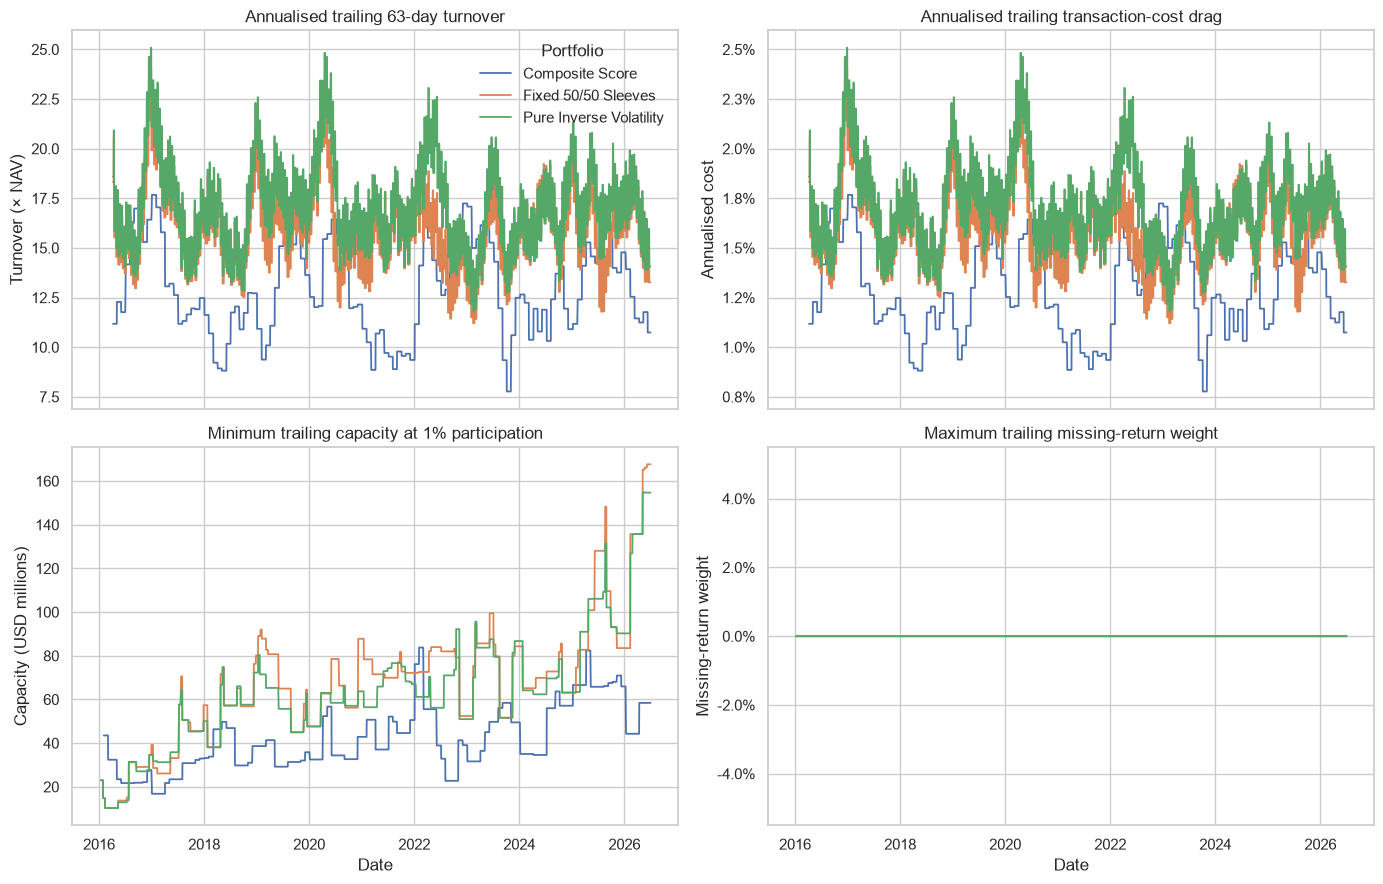

In [54]:
implementation_plot_data = implementation_daily.copy()

implementation_plot_data["minimum_trade_capacity_1pct_usd_millions_63"] = (
    implementation_plot_data["minimum_trade_capacity_1pct_usd_63"] / 1_000_000
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
)


IMPLEMENTATION_PLOT_SPECIFICATIONS = [
    (
        "annualised_turnover_63",
        "Annualised trailing 63-day turnover",
        "Turnover (× NAV)",
        False,
    ),
    (
        "annualised_transaction_cost_63",
        "Annualised trailing transaction-cost drag",
        "Annualised cost",
        True,
    ),
    (
        "minimum_trade_capacity_1pct_usd_millions_63",
        "Minimum trailing capacity at 1% participation",
        "Capacity (USD millions)",
        False,
    ),
    (
        "maximum_missing_return_weight_63",
        "Maximum trailing missing-return weight",
        "Missing-return weight",
        True,
    ),
]


for axis, (
    metric,
    title,
    ylabel,
    percentage_axis,
) in zip(
    axes.flat,
    IMPLEMENTATION_PLOT_SPECIFICATIONS,
):
    sns.lineplot(
        data=implementation_plot_data,
        x="date",
        y=metric,
        hue="portfolio",
        hue_order=PORTFOLIO_ORDER,
        ax=axis,
        linewidth=1.3,
        legend=(axis is axes[0, 0]),
    )

    axis.set_title(title)
    axis.set_xlabel("Date")
    axis.set_ylabel(ylabel)

    if percentage_axis:
        axis.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda value, _: f"{value:.1%}")
        )


axes[0, 0].legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

### Implementation-health summary

The selected implementations remain operationally healthy. Trailing annualised turnover is 10.7 times NAV for Composite Score and 13.3–14.1 times NAV for the sleeve portfolios, placing all three near the lower end of their historical distributions. At the assumed cost of 10 bps per unit of turnover, this produces annualised transaction-cost drag of approximately 1.1%–1.4%.

Recent trading demand is not unusually concentrated. The largest security trades observed during the trailing 63 days are approximately 4.7%–5.5% of NAV, below the historical tenth percentiles for all three portfolios.

Liquidity conditions are favourable. All traded weight has valid lagged dollar-volume coverage. At a 1% participation rate, trailing minimum implied capacity is approximately $58 million for Composite Score, $168 million for Fixed 50/50 Sleeves and $155 million for Pure Inverse Volatility. These values are toward the upper end of their historical distributions. The latest rebalance-event bottlenecks are higher still, at approximately $101 million, $252 million and $255 million, respectively.

No active missing-return exposure is present. The zero missing-return weight throughout the sample represents complete coverage rather than an adverse historical percentile.

Overall, Section 5 produces no implementation-health warning. Current turnover, cost pressure and trade sizes are relatively subdued, while liquidity and implied capacity are comparatively strong. These results do not remove the elevated market-exposure and concentration warnings identified in Sections 3 and 4, but they indicate that those risks are not currently accompanied by deteriorating implementation conditions.

## 6. Diagnostic Flags

This section converts the preceding diagnostics into a concise monitoring table.

The flags are descriptive research heuristics rather than trading rules. They do not alter the frozen portfolio specifications or trigger automatic portfolio changes.

Three types of condition are distinguished:

1. **Structural breaches** identify failures of expected data or implementation conditions, such as incomplete coverage or non-zero missing-return exposure.
2. **Historically calibrated warnings** identify metrics currently located in an adverse tail of their own historical distributions.
3. **Presentation choices** determine how the results are labelled and summarised, but have no economic significance by themselves.

The flag set focuses on non-redundant diagnostics:

- retained-signal coverage and rolling IC;
- portfolio beta, volatility and drawdown;
- sector, beta-contributor and realised-contribution concentration;
- turnover, trade size, capacity and missing-return exposure.

Transaction cost per unit of turnover is not separately flagged because it is mechanically fixed at 10 basis points by the backtest cost model. Transaction-cost drag therefore contains essentially the same information as turnover. Liquidity coverage remains a structural audit rather than a historically calibrated warning.

### Flag taxonomy

| Diagnostic | Adverse direction | Calibration |
|---|---:|---|
| Signal coverage | Lower | Structural requirement |
| Rolling IC | Lower | Historical lower tail |
| Absolute portfolio beta | Higher | Historical upper tail |
| Rolling volatility | Higher | Historical upper tail |
| Drawdown severity | Higher | Historical upper tail |
| Net sector exposure | Higher in absolute value | Historical upper tail |
| Beta-contributor concentration | Higher | Historical upper tail |
| Return-contribution concentration | Higher | Historical upper tail |
| Turnover | Higher | Historical upper tail |
| Largest trade weight | Higher | Historical upper tail |
| Implied capacity | Lower | Historical lower tail |
| Missing-return weight | Above zero | Structural requirement |

Historical thresholds will be estimated separately for each comparable entity. A warning therefore means that the current value is unusual relative to that portfolio's or signal's own history, not that the same absolute limit applies to every portfolio.

#### Flag configuration and helpers

In [56]:
HISTORICAL_LOWER_TAIL = 0.10
HISTORICAL_UPPER_TAIL = 0.90
STRUCTURAL_COVERAGE_TOLERANCE = 1e-8


diagnostic_flag_rows = []


def append_structural_flag(
    *,
    entity_type,
    entity,
    category,
    diagnostic,
    latest_date,
    latest_value,
    passes,
    calibration,
    threshold_value=np.nan,
    notes="",
):
    if pd.isna(latest_value) or passes is None or pd.isna(passes):
        status = "UNAVAILABLE"
    else:
        status = "PASS" if bool(passes) else "BREACH"

    diagnostic_flag_rows.append(
        {
            "entity_type": entity_type,
            "entity": entity,
            "category": category,
            "diagnostic": diagnostic,
            "latest_date": latest_date,
            "latest_value": latest_value,
            "adverse_direction": ("Structural failure"),
            "calibration": calibration,
            "threshold_value": threshold_value,
            "historical_percentile": np.nan,
            "status": status,
            "notes": notes,
        }
    )


def append_historical_flag(
    *,
    entity_type,
    entity,
    category,
    diagnostic,
    latest_date,
    latest_value,
    history,
    adverse_direction,
    notes="",
):
    valid_history = pd.to_numeric(
        history,
        errors="coerce",
    ).dropna()

    if pd.isna(latest_value) or valid_history.empty or valid_history.nunique() <= 1:
        threshold_value = np.nan
        historical_percentile = np.nan
        status = "UNAVAILABLE"
    else:
        historical_percentile = valid_history.le(latest_value).mean()

        if adverse_direction == "Higher":
            threshold_value = valid_history.quantile(HISTORICAL_UPPER_TAIL)

            warning = latest_value > threshold_value

            calibration = "Historical upper 10% tail"

        elif adverse_direction == "Lower":
            threshold_value = valid_history.quantile(HISTORICAL_LOWER_TAIL)

            warning = latest_value < threshold_value

            calibration = "Historical lower 10% tail"

        else:
            raise ValueError("adverse_direction must be " "'Higher' or 'Lower'.")

        status = "WARNING" if warning else "PASS"

    if valid_history.empty or valid_history.nunique() <= 1:
        calibration = "Historical calibration unavailable"

    diagnostic_flag_rows.append(
        {
            "entity_type": entity_type,
            "entity": entity,
            "category": category,
            "diagnostic": diagnostic,
            "latest_date": latest_date,
            "latest_value": latest_value,
            "adverse_direction": adverse_direction,
            "calibration": calibration,
            "threshold_value": threshold_value,
            "historical_percentile": (historical_percentile),
            "status": status,
            "notes": notes,
        }
    )

#### Structural coverage and data-quality flags

In [57]:
# Retained-signal coverage

for factor_name in FACTOR_COLUMNS:
    factor_data = signal_health_daily.loc[
        signal_health_daily["factor"].eq(factor_name)
    ].sort_values("date")

    latest_row = factor_data.iloc[-1]

    universe_observations = latest_row["universe_observations"]

    signal_observations = latest_row["signal_observations"]

    required_coverage = MIN_CROSS_SECTIONAL_OBSERVATIONS / universe_observations

    append_structural_flag(
        entity_type="Factor",
        entity=factor_name,
        category="Signal",
        diagnostic="Signal coverage",
        latest_date=latest_row["date"],
        latest_value=(latest_row["signal_coverage"]),
        passes=(signal_observations >= MIN_CROSS_SECTIONAL_OBSERVATIONS),
        calibration=(
            "At least "
            f"{MIN_CROSS_SECTIONAL_OBSERVATIONS} "
            "cross-sectional observations"
        ),
        threshold_value=required_coverage,
        notes=(
            f"{int(signal_observations)} of "
            f"{int(universe_observations)} "
            "observations available"
        ),
    )


# Portfolio-level structural checks

for portfolio_name in PORTFOLIO_ORDER:
    latest_beta_row = (
        beta_state_daily.loc[beta_state_daily["portfolio"].eq(portfolio_name)]
        .sort_values("date")
        .iloc[-1]
    )

    append_structural_flag(
        entity_type="Portfolio",
        entity=portfolio_name,
        category="Market risk",
        diagnostic="Holdings beta coverage",
        latest_date=latest_beta_row["date"],
        latest_value=(latest_beta_row["beta_coverage"]),
        passes=(
            latest_beta_row["beta_coverage"] >= (1.0 - STRUCTURAL_COVERAGE_TOLERANCE)
        ),
        calibration=("Complete beta coverage"),
        threshold_value=1.0,
    )

    latest_liquidity_row = (
        liquidity_coverage_daily.loc[
            liquidity_coverage_daily["portfolio"].eq(portfolio_name)
        ]
        .sort_values("date")
        .iloc[-1]
    )

    append_structural_flag(
        entity_type="Portfolio",
        entity=portfolio_name,
        category="Implementation",
        diagnostic="Liquidity coverage",
        latest_date=(latest_liquidity_row["date"]),
        latest_value=(latest_liquidity_row["liquidity_coverage"]),
        passes=(
            latest_liquidity_row["liquidity_coverage"]
            >= (1.0 - STRUCTURAL_COVERAGE_TOLERANCE)
        ),
        calibration=("Complete traded-weight coverage"),
        threshold_value=1.0,
    )

    latest_implementation_row = (
        implementation_daily.loc[implementation_daily["portfolio"].eq(portfolio_name)]
        .sort_values("date")
        .iloc[-1]
    )

    append_structural_flag(
        entity_type="Portfolio",
        entity=portfolio_name,
        category="Implementation",
        diagnostic=("Trailing missing-return weight"),
        latest_date=(latest_implementation_row["date"]),
        latest_value=(latest_implementation_row["maximum_missing_return_weight_63"]),
        passes=(
            latest_implementation_row["maximum_missing_return_weight_63"]
            <= STRUCTURAL_COVERAGE_TOLERANCE
        ),
        calibration=("No missing-return exposure"),
        threshold_value=0.0,
    )

#### Signal and portfolio-risk warnings

In [58]:
# Rolling predictive-health flags

for factor_name in FACTOR_COLUMNS:
    factor_data = signal_health_daily.loc[
        signal_health_daily["factor"].eq(factor_name)
    ].sort_values("date")

    predictive_history = factor_data.dropna(
        subset=[
            "rolling_mean_ic_252",
        ]
    )

    if predictive_history.empty:
        latest_date = factor_data["date"].max()
        latest_value = np.nan
    else:
        latest_predictive_row = predictive_history.iloc[-1]

        latest_date = latest_predictive_row["date"]

        latest_value = latest_predictive_row["rolling_mean_ic_252"]

    append_historical_flag(
        entity_type="Factor",
        entity=factor_name,
        category="Signal",
        diagnostic=("252-observation rolling mean IC"),
        latest_date=latest_date,
        latest_value=latest_value,
        history=(predictive_history["rolling_mean_ic_252"]),
        adverse_direction="Lower",
        notes=("Uses the latest date with " "observable five-day forward returns"),
    )


# Portfolio market-risk and drawdown flags

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_risk = (
        performance_risk_daily.loc[
            performance_risk_daily["portfolio"].eq(portfolio_name)
        ]
        .sort_values("date")
        .copy()
    )

    latest_risk_row = portfolio_risk.iloc[-1]

    append_historical_flag(
        entity_type="Portfolio",
        entity=portfolio_name,
        category="Market risk",
        diagnostic=("Annualised volatility (126 days)"),
        latest_date=latest_risk_row["date"],
        latest_value=(latest_risk_row["annualised_volatility_126"]),
        history=(portfolio_risk["annualised_volatility_126"]),
        adverse_direction="Higher",
    )

    portfolio_risk["drawdown_severity"] = -portfolio_risk["drawdown"]

    append_historical_flag(
        entity_type="Portfolio",
        entity=portfolio_name,
        category="Market risk",
        diagnostic="Current drawdown severity",
        latest_date=latest_risk_row["date"],
        latest_value=(-latest_risk_row["drawdown"]),
        history=(portfolio_risk["drawdown_severity"]),
        adverse_direction="Higher",
    )

    portfolio_beta = (
        beta_state_daily.loc[beta_state_daily["portfolio"].eq(portfolio_name)]
        .sort_values("date")
        .copy()
    )

    portfolio_beta["absolute_holdings_market_beta"] = portfolio_beta[
        "holdings_market_beta"
    ].abs()

    latest_beta_row = portfolio_beta.iloc[-1]

    append_historical_flag(
        entity_type="Portfolio",
        entity=portfolio_name,
        category="Market risk",
        diagnostic=("Absolute holdings-implied beta"),
        latest_date=latest_beta_row["date"],
        latest_value=(latest_beta_row["absolute_holdings_market_beta"]),
        history=(portfolio_beta["absolute_holdings_market_beta"]),
        adverse_direction="Higher",
        notes=(
            "Holdings-implied beta is used as " "the contemporaneous exposure measure"
        ),
    )

#### Concentration and implementation warnings

In [59]:
CONCENTRATION_FLAG_METRICS = {
    "largest_absolute_sector_net_exposure": {
        "diagnostic": ("Largest absolute sector net exposure"),
        "adverse_direction": "Higher",
    },
    "top_five_absolute_beta_contribution_share": {
        "diagnostic": ("Top-five absolute beta-contribution share"),
        "adverse_direction": "Higher",
    },
    "top_five_contributor_share_63": {
        "diagnostic": ("Top-five 63-day security-contribution share"),
        "adverse_direction": "Higher",
    },
    "effective_contribution_sector_count_63": {
        "diagnostic": ("Effective 63-day contribution sectors"),
        "adverse_direction": "Lower",
    },
}


for portfolio_name in PORTFOLIO_ORDER:
    portfolio_concentration = concentration_state_daily.loc[
        concentration_state_daily["portfolio"].eq(portfolio_name)
    ].sort_values("date")

    latest_concentration_row = portfolio_concentration.iloc[-1]

    for (
        metric,
        specification,
    ) in CONCENTRATION_FLAG_METRICS.items():
        append_historical_flag(
            entity_type="Portfolio",
            entity=portfolio_name,
            category="Concentration",
            diagnostic=(specification["diagnostic"]),
            latest_date=(latest_concentration_row["date"]),
            latest_value=(latest_concentration_row[metric]),
            history=(portfolio_concentration[metric]),
            adverse_direction=(specification["adverse_direction"]),
        )


IMPLEMENTATION_FLAG_METRICS = {
    "annualised_turnover_63": {
        "diagnostic": ("Annualised trailing turnover"),
        "adverse_direction": "Higher",
    },
    "largest_trade_weight_63": {
        "diagnostic": ("Largest trailing trade weight"),
        "adverse_direction": "Higher",
    },
    "minimum_trade_capacity_1pct_usd_63": {
        "diagnostic": ("Minimum trailing capacity at 1%"),
        "adverse_direction": "Lower",
    },
}


for portfolio_name in PORTFOLIO_ORDER:
    portfolio_implementation = implementation_daily.loc[
        implementation_daily["portfolio"].eq(portfolio_name)
    ].sort_values("date")

    latest_implementation_row = portfolio_implementation.iloc[-1]

    for (
        metric,
        specification,
    ) in IMPLEMENTATION_FLAG_METRICS.items():
        append_historical_flag(
            entity_type="Portfolio",
            entity=portfolio_name,
            category="Implementation",
            diagnostic=(specification["diagnostic"]),
            latest_date=(latest_implementation_row["date"]),
            latest_value=(latest_implementation_row[metric]),
            history=(portfolio_implementation[metric]),
            adverse_direction=(specification["adverse_direction"]),
        )

#### Consolidated flag tables

In [61]:
diagnostic_flags = pd.DataFrame(diagnostic_flag_rows)


EXPECTED_FLAG_COLUMNS = {
    "entity_type",
    "entity",
    "category",
    "diagnostic",
    "latest_date",
    "latest_value",
    "adverse_direction",
    "calibration",
    "threshold_value",
    "historical_percentile",
    "status",
    "notes",
}

missing_flag_columns = EXPECTED_FLAG_COLUMNS - set(diagnostic_flags.columns)

if missing_flag_columns:
    raise KeyError(
        "Diagnostic flags are missing columns: " f"{sorted(missing_flag_columns)}"
    )


if diagnostic_flags.duplicated(
    [
        "entity_type",
        "entity",
        "category",
        "diagnostic",
    ]
).any():
    raise ValueError("Duplicate diagnostic flags found.")


STATUS_SEVERITY = {
    "PASS": 0,
    "WARNING": 1,
    "UNAVAILABLE": 2,
    "BREACH": 3,
}

SEVERITY_STATUS = {severity: status for status, severity in STATUS_SEVERITY.items()}

ENTITY_ORDER = {
    entity: position
    for position, entity in enumerate(
        [
            *FACTOR_COLUMNS.keys(),
            *PORTFOLIO_ORDER,
        ]
    )
}

CATEGORY_ORDER = {
    category: position
    for position, category in enumerate(
        [
            "Signal",
            "Market risk",
            "Concentration",
            "Implementation",
        ]
    )
}


diagnostic_flags["status_severity"] = diagnostic_flags["status"].map(STATUS_SEVERITY)

diagnostic_flags["entity_order"] = diagnostic_flags["entity"].map(ENTITY_ORDER)

diagnostic_flags["category_order"] = diagnostic_flags["category"].map(CATEGORY_ORDER)


diagnostic_flags = (
    diagnostic_flags.sort_values(
        [
            "entity_order",
            "category_order",
            "diagnostic",
        ]
    )
    .drop(
        columns=[
            "entity_order",
            "category_order",
        ]
    )
    .reset_index(drop=True)
)


diagnostic_flag_summary = (
    diagnostic_flags.groupby(
        [
            "entity_type",
            "entity",
        ],
        sort=False,
    )
    .agg(
        diagnostics=(
            "status",
            "size",
        ),
        passes=(
            "status",
            lambda values: (values.eq("PASS").sum()),
        ),
        warnings=(
            "status",
            lambda values: (values.eq("WARNING").sum()),
        ),
        breaches=(
            "status",
            lambda values: (values.eq("BREACH").sum()),
        ),
        unavailable=(
            "status",
            lambda values: (values.eq("UNAVAILABLE").sum()),
        ),
        maximum_status_severity=(
            "status_severity",
            "max",
        ),
    )
    .reset_index()
)


diagnostic_flag_summary["overall_status"] = diagnostic_flag_summary[
    "maximum_status_severity"
].map(SEVERITY_STATUS)

diagnostic_flag_summary = diagnostic_flag_summary.drop(
    columns=[
        "maximum_status_severity",
    ]
).set_index(
    [
        "entity_type",
        "entity",
    ]
)


category_status_long = (
    diagnostic_flags.groupby(
        [
            "entity_type",
            "entity",
            "category",
        ],
        sort=False,
    )["status_severity"]
    .max()
    .map(SEVERITY_STATUS)
    .rename("status")
    .reset_index()
)


monitoring_flag_matrix = category_status_long.pivot(
    index=[
        "entity_type",
        "entity",
    ],
    columns="category",
    values="status",
).reindex(
    columns=[
        "Signal",
        "Market risk",
        "Concentration",
        "Implementation",
    ]
)


active_diagnostic_flags = (
    diagnostic_flags.loc[diagnostic_flags["status"].ne("PASS")]
    .sort_values(
        [
            "status_severity",
            "entity_type",
            "entity",
            "category",
            "diagnostic",
        ],
        ascending=[
            False,
            True,
            True,
            True,
            True,
        ],
    )[
        [
            "entity_type",
            "entity",
            "category",
            "diagnostic",
            "latest_date",
            "latest_value",
            "adverse_direction",
            "calibration",
            "threshold_value",
            "historical_percentile",
            "status",
            "notes",
        ]
    ]
    .reset_index(drop=True)
)


display(diagnostic_flag_summary)

# display(monitoring_flag_matrix)
monitoring_flag_matrix_display = (monitoring_flag_matrix.fillna("N/A"))
display(monitoring_flag_matrix_display)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_colwidth",
    None,
):
    display(active_diagnostic_flags.round(6))

diagnostics  passes  warnings  breaches  unavailable overall_status
entity_type entity                                                                                      
Factor      Momentum                           2       2         0         0            0           PASS
            Realised Volatility                2       2         0         0            0           PASS
Portfolio   Composite Score                   13       7         6         0            0        WARNING
            Fixed 50/50 Sleeves               13       7         6         0            0        WARNING
            Pure Inverse Volatility           13       7         6         0            0        WARNING

category                            Signal Market risk Concentration Implementation
entity_type entity                                                                 
Factor      Momentum                  PASS         N/A           N/A            N/A
            Realised Volatility       PASS         N/A           N/A            N/A
Portfolio   Composite Score            N/A     WARNING       WARNING           PASS
            Fixed 50/50 Sleeves        N/A     WARNING       WARNING           PASS
            Pure Inverse Volatility    N/A     WARNING       WARNING           PASS

C:\Users\39521\AppData\Local\Temp\ipykernel_12180\774793087.py:231: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(active_diagnostic_flags.round(6))


,entity_type,entity,category,diagnostic,latest_date,latest_value,adverse_direction,calibration,threshold_value,historical_percentile,status,notes
0,Portfolio,Composite Score,Concentration,Effective 63-day contribution sectors,2026-07-01,3.212705,Lower,Historical lower 10% tail,4.216922,0.000389,WARNING,
1,Portfolio,Composite Score,Concentration,Largest absolute sector net exposure,2026-07-01,0.679429,Higher,Historical upper 10% tail,0.520167,0.995825,WARNING,
2,Portfolio,Composite Score,Concentration,Top-five 63-day security-contribution share,2026-07-01,0.290632,Higher,Historical upper 10% tail,0.257575,1.000000,WARNING,
3,Portfolio,Composite Score,Concentration,Top-five absolute beta-contribution share,2026-07-01,0.379819,Higher,Historical upper 10% tail,0.316679,0.996205,WARNING,
4,Portfolio,Composite Score,Market risk,Absolute holdings-implied beta,2026-07-01,1.827265,Higher,Historical upper 10% tail,1.375530,0.995446,WARNING,Holdings-implied beta is used as the contemporaneous exposure measure
5,Portfolio,Composite Score,Market risk,Annualised volatility (126 days),2026-07-01,0.367481,Higher,Historical upper 10% tail,0.275731,1.000000,WARNING,
6,Portfolio,Fixed 50/50 Sleeves,Concentration,Effective 63-day contribution sectors,2026-07-01,3.206939,Lower,Historical lower 10% tail,4.158835,0.000777,WARNING,
7,Portfolio,Fixed 50/50 Sleeves,Concentration,Largest absolute sector net exposure,2026-07-01,0.449092,Higher,Historical upper 10% tail,0.420380,0.950285,WARNING,
8,Portfolio,Fixed 50/50 Sleeves,Concentration,Top-five 63-day security-contribution share,2026-07-01,0.346739,Higher,Historical upper 10% tail,0.288583,1.000000,WARNING,
9,Portfolio,Fixed 50/50 Sleeves,Concentration,Top-five absolute beta-contribution share,2026-07-01,0.419225,Higher,Historical upper 10% tail,0.359644,0.985958,WARNING,


### Diagnostic-flag summary

The monitoring framework identifies a consistent current risk regime across all three selected implementations. Both retained factors pass their structural coverage and rolling predictive-health checks. There are no structural breaches or unavailable diagnostics, and all implementation-health flags pass.

Each portfolio nevertheless receives six historically calibrated warnings. These warnings are concentrated entirely in market risk and portfolio concentration:

- absolute holdings-implied beta is above its historical 90th percentile;
- annualised 126-day volatility is above its historical 90th percentile;
- absolute sector net exposure is unusually high;
- beta contributions are unusually concentrated among the five largest contributors;
- realised 63-day return contributions are unusually concentrated among five securities; and
- the effective number of contributing sectors is unusually low.

The warnings describe a related cluster rather than six independent failures. Concentrated sector positioning and security-level beta contributions are accompanied by elevated whole-portfolio beta and volatility, while recent realised performance has depended on an unusually narrow group of securities and sectors.

Composite Score displays the largest absolute exposures. Its holdings-implied beta is 1.83, compared with a historical 90th-percentile threshold of 1.38, while annualised 126-day volatility is 36.7%, compared with a threshold of 27.6%. Its largest absolute sector net exposure is 67.9% of NAV, also close to the most extreme value in its history.

Fixed 50/50 Sleeves and Pure Inverse Volatility have lower absolute beta and volatility than Composite Score, at approximately 1.41 beta and 30.1% annualised volatility. However, both remain close to the most adverse ends of their own historical distributions and show similarly elevated contribution concentration.

Current drawdown severity does not trigger a warning. The portfolios are therefore operating in a high-beta, high-volatility and highly concentrated regime, but this has not yet developed into an unusually severe drawdown. Implementation conditions also remain favourable: turnover and trade sizes are subdued, liquidity coverage is complete, implied capacity is strong and no missing-return exposure is present.

Overall, the monitoring result is **WARNING**, not **BREACH**. The strategy definitions remain frozen, and the findings do not mechanically trigger portfolio changes. They indicate that current performance should be interpreted cautiously because market exposure and realised contributions are substantially more concentrated than usual.

## 7. Consolidated Findings, Exports and Handoff

This section consolidates the monitoring evidence, saves the reusable outputs and defines the handoff to the final strategy-selection notebook.

### 7.1 Consolidated findings

#### 1. Signal health remains satisfactory

- Momentum and realised volatility are available for 100 of 101 securities.
- Their latest 252-day rolling mean rank ICs remain positive, at 0.055 and 0.044.
- Signal rankings are stable, cross-sectional dispersion remains healthy and cross-factor dependence is low.
- Both retained factors pass their structural and historically calibrated monitoring checks.

#### 2. Portfolio risk is unusually elevated

- Holdings-implied portfolio beta ranges from 1.41 to 1.83.
- Annualised 126-day volatility ranges from approximately 30% to 37%.
- Both measures are above their respective historical 90th-percentile thresholds for all three implementations.
- The short baskets currently provide little beta offset to the higher-beta long baskets.

#### 3. Risk and performance are concentrated

- Information Technology represents approximately one third of gross exposure and generates the largest net sector imbalance.
- The five largest beta contributors account for approximately 38%–42% of absolute beta contribution.
- The five largest security contributors account for approximately 29%–35% of trailing absolute return contribution.
- Only about three effective sectors currently drive trailing realised contributions.

Nominal position counts remain reasonably diversified, but diversification is materially weaker when measured by beta and realised contribution.

#### 4. Implementation conditions remain healthy

- Turnover and transaction-cost pressure are near the lower ends of their historical distributions.
- Recent security-level trade sizes are not unusually large.
- Liquidity coverage is complete and trailing implied capacity remains comparatively strong.
- No active missing-return exposure or other structural implementation breach is present.

#### 5. Overall monitoring conclusion

The latest monitoring status is **WARNING**, not **BREACH**.

The warnings form one connected risk cluster: concentrated sector positioning and beta contributions are accompanied by elevated portfolio beta, volatility and realised-contribution concentration. They should not be interpreted as six independent failures per portfolio.

Strong recent performance has therefore occurred in an unusually concentrated, high-beta regime. However, the underlying signals, data quality and operational implementation remain healthy, and the current drawdown has not crossed its historically calibrated warning threshold.

Notebook 08 identifies and documents this state without changing the frozen strategy definitions. Whether these exposures are acceptable—and whether explicit beta or sector controls should be investigated—remains a portfolio-design decision rather than an automatic monitoring response.

In [ ]:
latest_monitoring_overview = (
    diagnostic_flag_summary.join(
        monitoring_flag_matrix,
        how="left",
    )
    .rename(
        columns={
            "Signal": "signal_status",
            "Market risk": "market_risk_status",
            "Concentration": "concentration_status",
            "Implementation": "implementation_status",
        }
    )
    .reset_index()
)


latest_monitoring_overview.columns.name = None


MONITORING_STATUS_COLUMNS = [
    "signal_status",
    "market_risk_status",
    "concentration_status",
    "implementation_status",
]


latest_monitoring_overview[MONITORING_STATUS_COLUMNS] = latest_monitoring_overview[
    MONITORING_STATUS_COLUMNS
].fillna("N/A")


display(latest_monitoring_overview)

,entity_type,entity,diagnostics,passes,warnings,breaches,unavailable,overall_status,signal_status,market_risk_status,concentration_status,implementation_status
0,Factor,Momentum,2,2,0,0,0,PASS,PASS,N/A,N/A,N/A
1,Factor,Realised Volatility,2,2,0,0,0,PASS,PASS,N/A,N/A,N/A
2,Portfolio,Composite Score,13,7,6,0,0,WARNING,N/A,WARNING,WARNING,PASS
3,Portfolio,Fixed 50/50 Sleeves,13,7,6,0,0,WARNING,N/A,WARNING,WARNING,PASS
4,Portfolio,Pure Inverse Volatility,13,7,6,0,0,WARNING,N/A,WARNING,WARNING,PASS


### 7.2 Reusable monitoring outputs

The exports are intentionally limited to stable, reusable monitoring tables.

| Output | Purpose |
|---|---|
| Signal-health history | Coverage, IC, dispersion and rank-stability monitoring |
| Factor-dependence history | Cross-factor correlation through time |
| Performance and risk history | Returns, volatility, Sharpe ratio and drawdown state |
| Beta history | Holdings-implied and realised market exposure |
| Concentration history | Position, sector, beta and contribution concentration |
| Implementation history | Turnover, costs, trade size, capacity and missing returns |
| Diagnostic flags | Latest values, thresholds, percentiles and statuses |
| Latest overview | Compact factor- and portfolio-level monitoring snapshot |

The existing attribution exports remain the canonical source for security-level holdings, trades and contributions. They are not duplicated here.

An additional export of `active_diagnostic_flags` is also unnecessary because it can be reproduced from the complete flag table by filtering for `status != "PASS"`.

In [63]:
BETA_MONITORING_EXPORT_COLUMNS = [
    "date",
    "portfolio",
    "beta_coverage",
    "holdings_market_beta",
    "realised_gross_beta_126",
    "realised_net_beta_126",
    "beta_measurement_gap",
    "holdings_long_beta_contribution",
    "holdings_short_beta_contribution",
    "realised_long_beta_126",
    "realised_short_beta_126",
    "long_basket_beta",
    "short_basket_beta",
]


DIAGNOSTIC_FLAG_EXPORT_COLUMNS = [
    "entity_type",
    "entity",
    "category",
    "diagnostic",
    "latest_date",
    "latest_value",
    "adverse_direction",
    "calibration",
    "threshold_value",
    "historical_percentile",
    "status",
    "status_severity",
    "notes",
]


diagnostic_flags_export = (
    diagnostic_flags[DIAGNOSTIC_FLAG_EXPORT_COLUMNS]
    .sort_values(
        [
            "entity_type",
            "entity",
            "category",
            "diagnostic",
        ]
    )
    .reset_index(drop=True)
)


strategy_monitoring_exports = {
    "strategy_monitoring_signal_health_daily.parquet": (
        signal_health_daily.sort_values(
            [
                "factor",
                "date",
            ]
        ).reset_index(drop=True)
    ),
    "strategy_monitoring_factor_dependence_daily.parquet": (
        factor_dependence_daily.sort_values("date").reset_index(drop=True)
    ),
    "strategy_monitoring_performance_risk_daily.parquet": (
        performance_risk_daily.sort_values(
            [
                "portfolio",
                "date",
            ]
        ).reset_index(drop=True)
    ),
    "strategy_monitoring_beta_daily.parquet": (
        beta_state_daily[BETA_MONITORING_EXPORT_COLUMNS]
        .sort_values(
            [
                "portfolio",
                "date",
            ]
        )
        .reset_index(drop=True)
    ),
    "strategy_monitoring_concentration_daily.parquet": (
        concentration_state_daily.sort_values(
            [
                "portfolio",
                "date",
            ]
        ).reset_index(drop=True)
    ),
    "strategy_monitoring_implementation_daily.parquet": (
        implementation_daily.sort_values(
            [
                "portfolio",
                "date",
            ]
        ).reset_index(drop=True)
    ),
    "strategy_monitoring_diagnostic_flags.parquet": (diagnostic_flags_export),
    "strategy_monitoring_latest_overview.parquet": (latest_monitoring_overview),
}


MONITORING_EXPORT_KEYS = {
    "strategy_monitoring_signal_health_daily.parquet": [
        "factor",
        "date",
    ],
    "strategy_monitoring_factor_dependence_daily.parquet": [
        "date",
    ],
    "strategy_monitoring_performance_risk_daily.parquet": [
        "portfolio",
        "date",
    ],
    "strategy_monitoring_beta_daily.parquet": [
        "portfolio",
        "date",
    ],
    "strategy_monitoring_concentration_daily.parquet": [
        "portfolio",
        "date",
    ],
    "strategy_monitoring_implementation_daily.parquet": [
        "portfolio",
        "date",
    ],
    "strategy_monitoring_diagnostic_flags.parquet": [
        "entity_type",
        "entity",
        "category",
        "diagnostic",
    ],
    "strategy_monitoring_latest_overview.parquet": [
        "entity_type",
        "entity",
    ],
}


for filename, dataframe in strategy_monitoring_exports.items():
    if dataframe.empty:
        raise ValueError(f"{filename} is empty.")

    key_columns = MONITORING_EXPORT_KEYS[filename]

    missing_key_columns = set(key_columns) - set(dataframe.columns)

    if missing_key_columns:
        raise KeyError(
            f"{filename} is missing key columns: " f"{sorted(missing_key_columns)}"
        )

    if dataframe.duplicated(key_columns).any():
        raise ValueError(f"{filename} contains duplicate keys.")


monitoring_export_inventory = pd.DataFrame(
    [
        {
            "file": filename,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
            "key": ", ".join(MONITORING_EXPORT_KEYS[filename]),
        }
        for filename, dataframe in strategy_monitoring_exports.items()
    ]
)


display(monitoring_export_inventory)

,file,rows,columns,key
0,strategy_monitoring_signal_health_daily.parquet,5782,23,"factor, date"
1,strategy_monitoring_factor_dependence_daily.pa...,2891,4,date
2,strategy_monitoring_performance_risk_daily.par...,10540,11,"portfolio, date"
3,strategy_monitoring_beta_daily.parquet,7905,13,"portfolio, date"
4,strategy_monitoring_concentration_daily.parquet,7905,27,"portfolio, date"
5,strategy_monitoring_implementation_daily.parquet,7905,21,"portfolio, date"
6,strategy_monitoring_diagnostic_flags.parquet,43,13,"entity_type, entity, category, diagnostic"
7,strategy_monitoring_latest_overview.parquet,5,12,"entity_type, entity"


In [64]:
monitoring_export_manifest_rows = []


for (
    filename,
    dataframe,
) in strategy_monitoring_exports.items():
    export_path = PROCESSED_DATA_DIR / filename

    dataframe.to_parquet(
        export_path,
        index=False,
    )

    saved_data = load_parquet(export_path)

    if saved_data.shape != dataframe.shape:
        raise ValueError("Read-back shape mismatch for " f"{filename}.")

    if saved_data.columns.tolist() != dataframe.columns.tolist():
        raise ValueError("Read-back column mismatch for " f"{filename}.")

    key_columns = MONITORING_EXPORT_KEYS[filename]

    if saved_data.duplicated(key_columns).any():
        raise ValueError("Read-back duplicate keys found for " f"{filename}.")

    date_column = next(
        (
            column
            for column in [
                "date",
                "latest_date",
            ]
            if column in saved_data.columns
        ),
        None,
    )

    monitoring_export_manifest_rows.append(
        {
            "file": filename,
            "rows": len(saved_data),
            "columns": saved_data.shape[1],
            "start_date": (
                saved_data[date_column].min() if date_column is not None else pd.NaT
            ),
            "end_date": (
                saved_data[date_column].max() if date_column is not None else pd.NaT
            ),
            "read_back_passes": True,
        }
    )


strategy_monitoring_export_manifest = pd.DataFrame(monitoring_export_manifest_rows)


display(strategy_monitoring_export_manifest)


print(
    "Exported all Notebook 08 monitoring " "outputs to:",
    PROCESSED_DATA_DIR,
)

,file,rows,columns,start_date,end_date,read_back_passes
0,strategy_monitoring_signal_health_daily.parquet,5782,23,2015-01-02,2026-07-02,True
1,strategy_monitoring_factor_dependence_daily.pa...,2891,4,2015-01-02,2026-07-02,True
2,strategy_monitoring_performance_risk_daily.par...,10540,11,2016-01-07,2026-07-01,True
3,strategy_monitoring_beta_daily.parquet,7905,13,2016-01-07,2026-07-01,True
4,strategy_monitoring_concentration_daily.parquet,7905,27,2016-01-07,2026-07-01,True
5,strategy_monitoring_implementation_daily.parquet,7905,21,2016-01-07,2026-07-01,True
6,strategy_monitoring_diagnostic_flags.parquet,43,13,2026-06-25,2026-07-02,True
7,strategy_monitoring_latest_overview.parquet,5,12,NaT,NaT,True


Exported all Notebook 08 monitoring outputs to: D:\dev\quant_projects\alpha-research-lab\data\processed


### 7.3 Notebook conclusion

Notebook 08 has converted the preceding research into a repeatable monitoring framework.

#### Completed

- Reconciled the frozen strategy inputs and accounting identities.
- Monitored retained-signal coverage, predictive health and dependence.
- Measured holdings-implied and realised market exposure.
- Tracked performance, volatility, downside risk and drawdowns.
- Evaluated position, sector, beta and realised-contribution concentration.
- Monitored turnover, costs, liquidity, capacity and missing returns.
- Separated structural breaches from historically calibrated warnings.
- Exported dashboard-ready histories and a consolidated latest snapshot.

#### Current assessment

The retained signals and implementation infrastructure remain healthy. The principal concern is the current combination of high market beta, high volatility and concentrated sector and return contributions.

This is a monitoring warning rather than evidence that the signals have failed or that the portfolios cannot be implemented. It nevertheless limits how confidently the strong recent performance can be treated as diversified alpha.

#### Handoff to Notebook 09

Notebook 09 will make the final implementation decision. It should compare the three retained portfolios using evidence already established in Notebooks 04–08, without reopening the factor search or optimising against the latest monitoring state.

The final decision should address:

1. which implementation is retained as the primary strategy;
2. which alternatives remain as transparent benchmarks;
3. the trade-off between performance, robustness, simplicity and risk concentration;
4. whether beta and sector controls belong in the current specification or in future research;
5. the strategy's main limitations and appropriate interpretation; and
6. the final exports, project conclusions and dashboard presentation.